Atividade 5

André Luiz Queiroz Valpassos

Luis Ernani Viniski

Leonardo Barbosa dos Santos

Gabriel Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
#Importando os dados
url = "https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2002/dados/country_data.csv"
df = pd.read_csv(url)

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
#Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
#Estatísticas do Dataset
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
#Verificando se existem linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [ ]:
df_filtered = df.drop(columns=['country','exports', 'imports'])
X = df_filtered

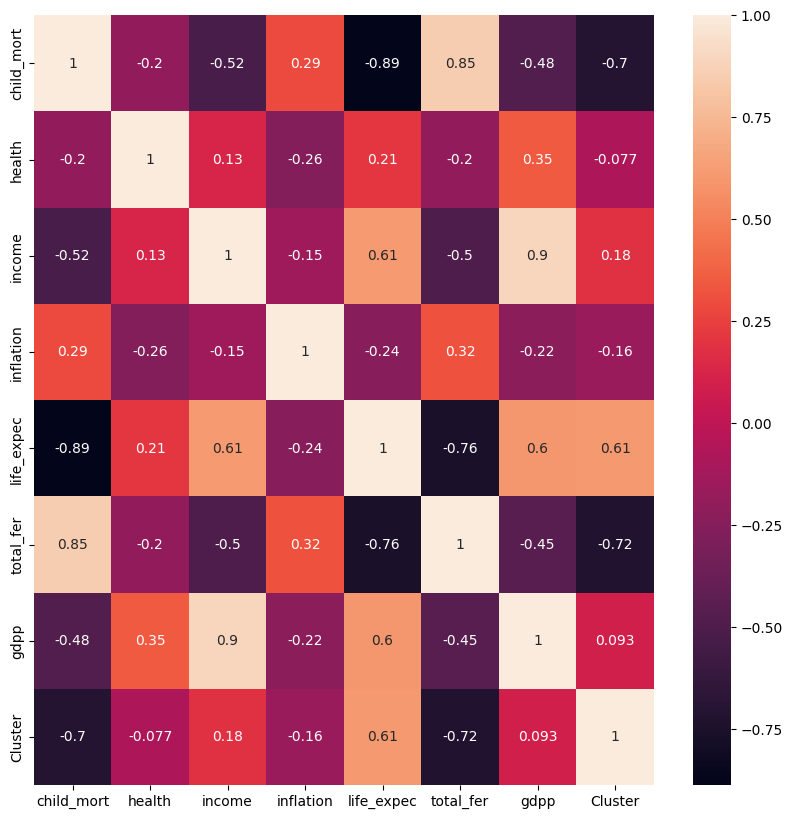

In [ ]:
plt.figure(figsize = (10, 10))
sns.heatmap(X.corr(), annot = True)
plt.savefig('Correlation')
plt.show()

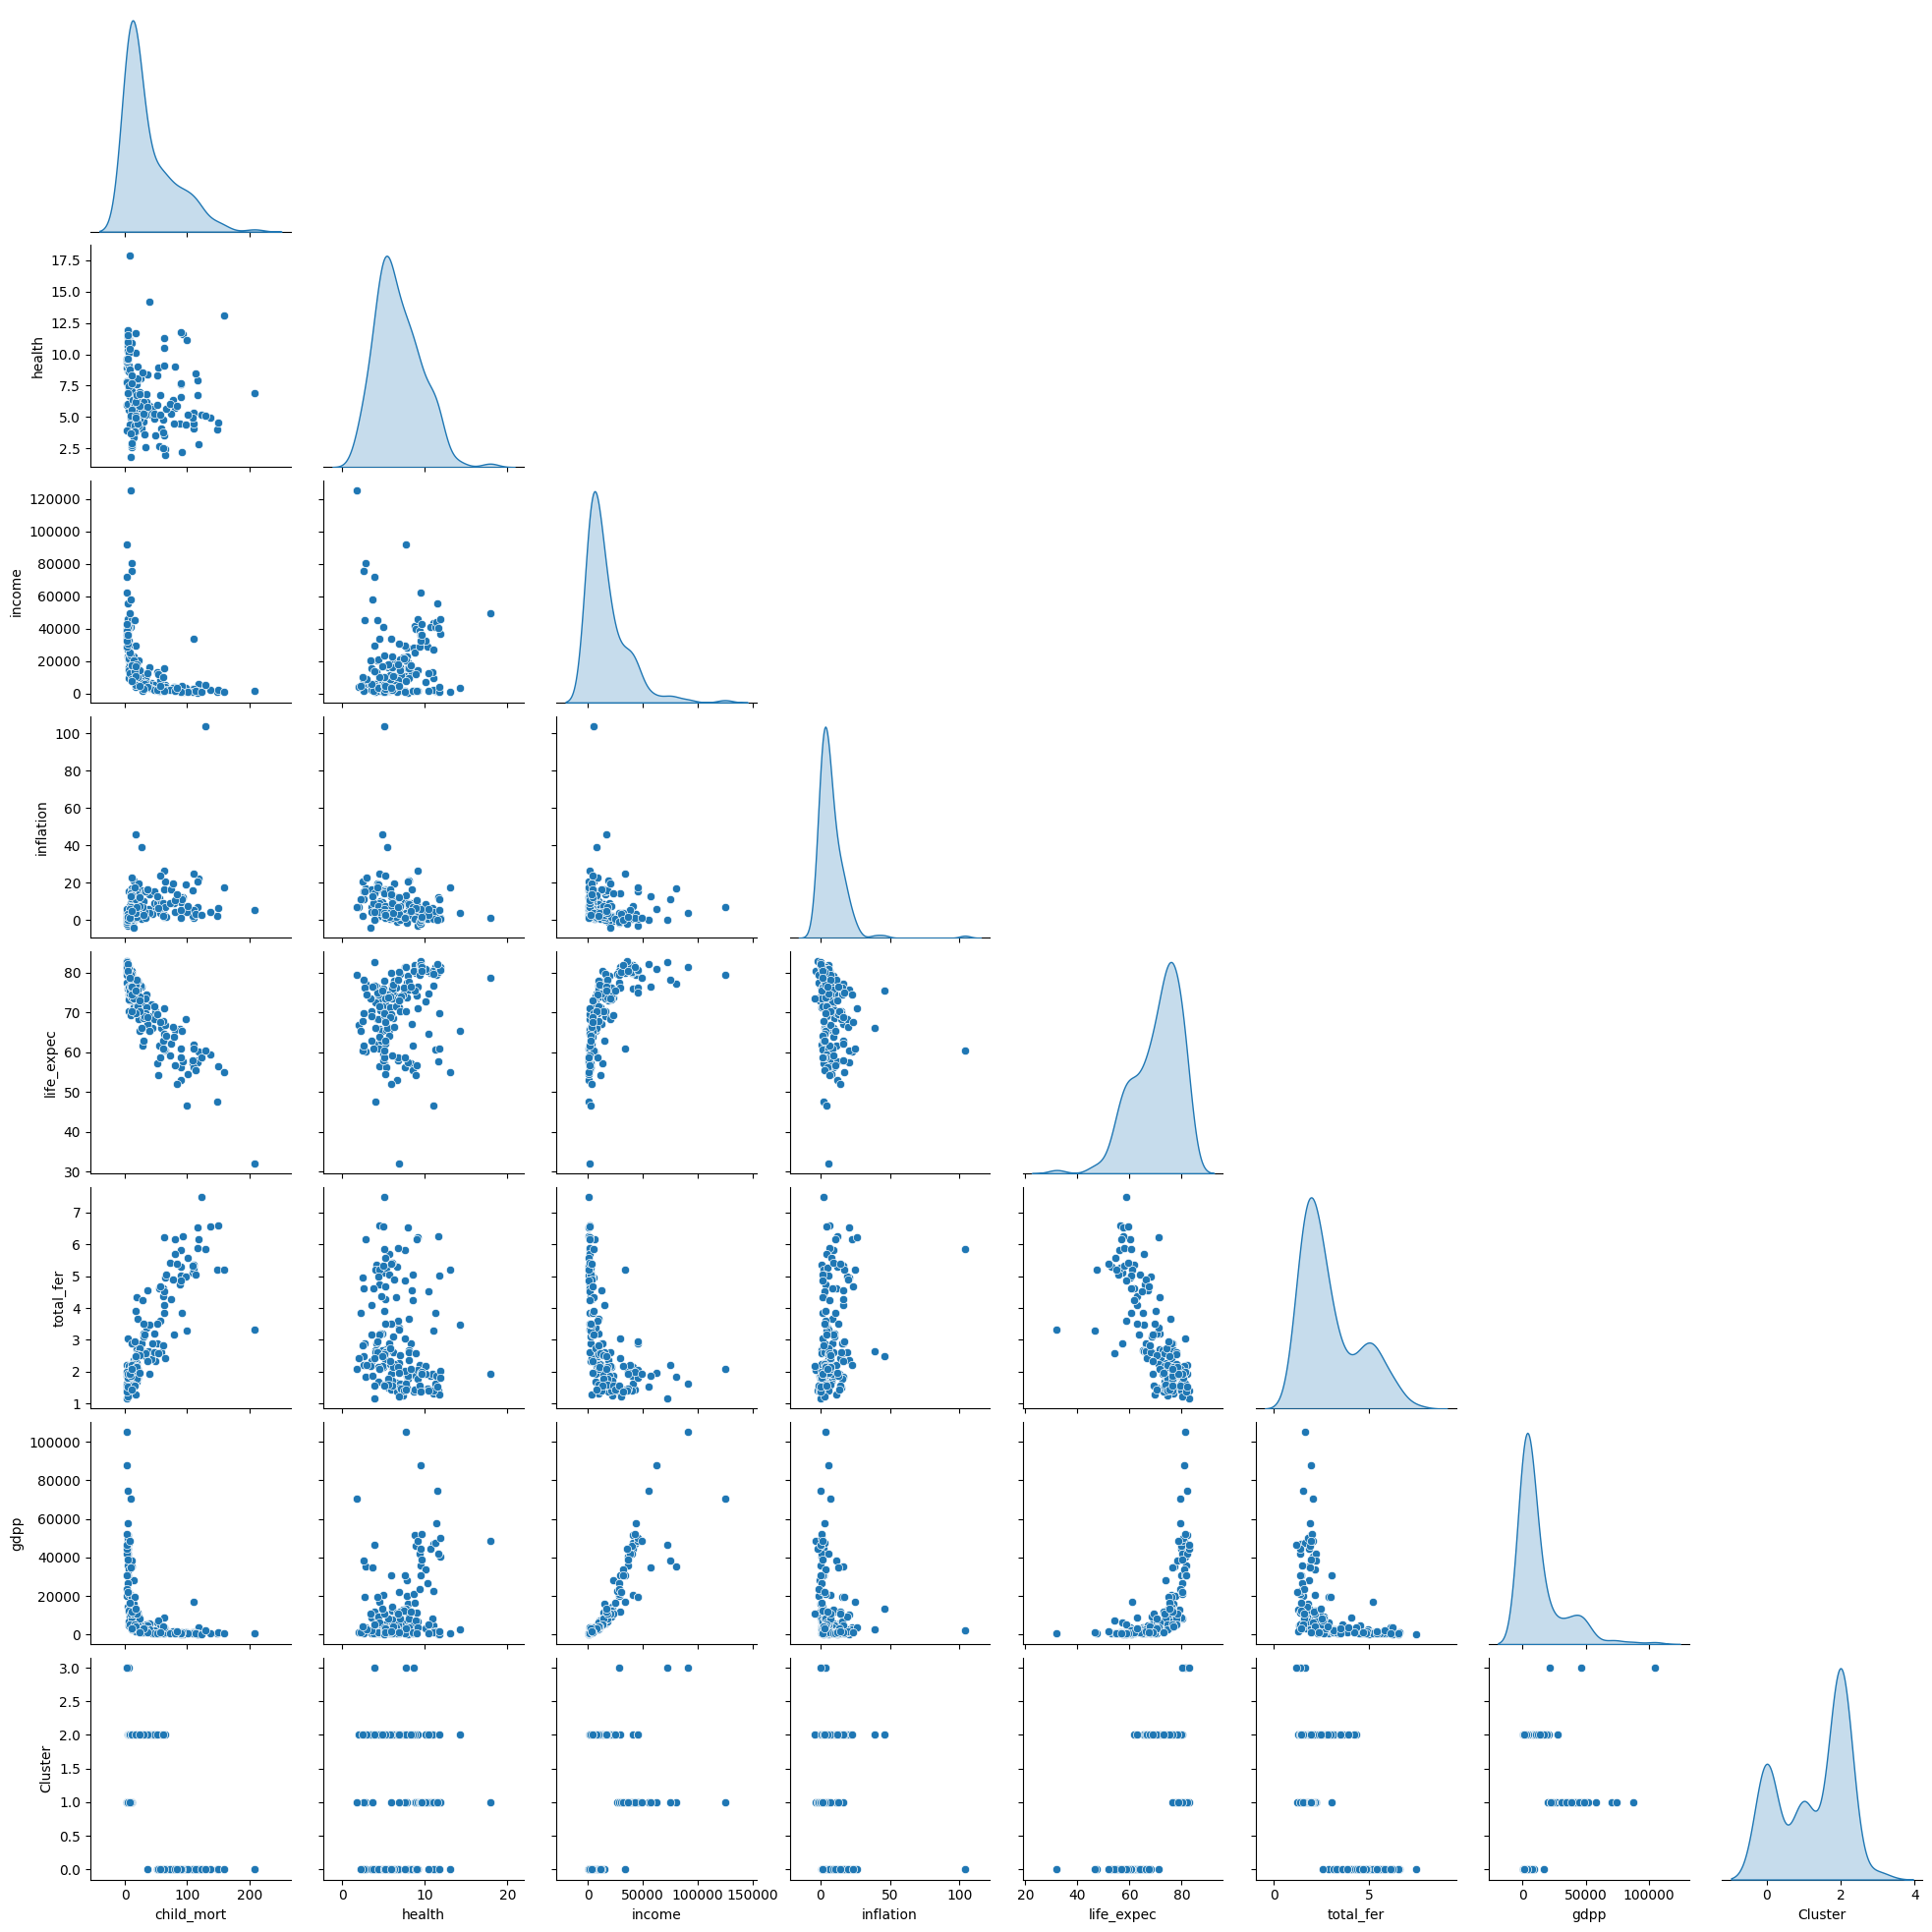

In [ ]:
sns.pairplot(X,corner=True,diag_kind="kde")
plt.show()

In [ ]:
# Inicializar o scaler
scaler = StandardScaler()

# Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PCA

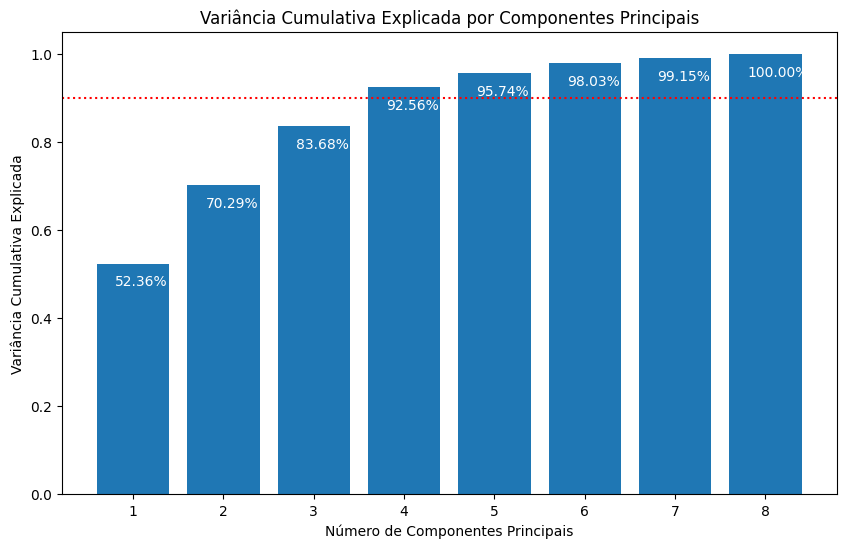

In [ ]:
from sklearn.decomposition import PCA

# Inicialize o PCA com o número de componentes desejado ou None para manter todos os componentes
n_components = None
pca = PCA(n_components=n_components)

# Ajuste o modelo PCA aos seus dados
pca.fit(X_scaled)

# Calcule a variância explicada cumulativa
explained_variance_ratio_cumulative = np.cumsum(pca.explained_variance_ratio_)

# Crie um gráfico da variância cumulativa
plt.figure(figsize=(10, 6))
bars = plt.bar(range(1, len(explained_variance_ratio_cumulative) + 1), explained_variance_ratio_cumulative)
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Cumulativa Explicada')
plt.title('Variância Cumulativa Explicada por Componentes Principais')
plt.axhline(y=0.9, c='red', linestyle=':')

# Adicione as porcentagens como rótulos nas barras
for bar, explained_variance in zip(bars, explained_variance_ratio_cumulative):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.2, bar.get_height() - 0.05, f'{explained_variance:.2%}', fontsize=10, color='white')

plt.show()

In [ ]:
#Escolhendo o número de principais componentes até ≈ 90% de variância explicada
pca = PCA(n_components=.95)





principalComponents = pca.fit_transform(X_scaled)

columns = []

for i in range(principalComponents.shape[1]):
  columns.append(f'Principal component {i}')

principalDf = pd.DataFrame(data = principalComponents, columns = columns)
principalDf

,Principal component 0,Principal component 1,Principal component 2,Principal component 3,Principal component 4
0,3.100671,-1.050396,-0.413896,-0.010907,0.090240
1,-0.902662,1.190794,-0.500428,0.095663,0.102133
2,-0.169904,1.396704,0.865018,0.182453,0.358541
3,3.663299,-0.475963,1.569003,-0.388141,0.288591
4,-1.215274,0.812608,-0.265144,-0.375327,0.182668
...,...,...,...,...,...
162,0.627585,1.110085,-0.530990,-0.527782,-0.346787
163,-0.103212,1.356556,2.791784,2.272888,-0.011970
164,-0.305724,1.297477,-0.227868,0.674507,-0.076402
165,2.130869,-0.169634,1.056717,0.603079,0.952801


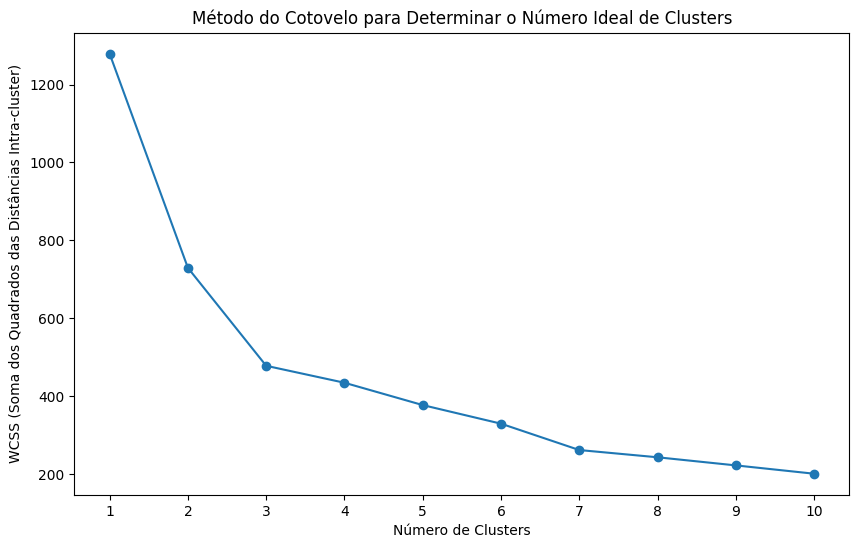

In [ ]:
# Determinar o número ideal de clusters usando o método do cotovelo
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(principalDf)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Método do Cotovelo para Determinar o Número Ideal de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Soma dos Quadrados das Distâncias Intra-cluster)')
plt.xticks(range(1, 11))
plt.show()

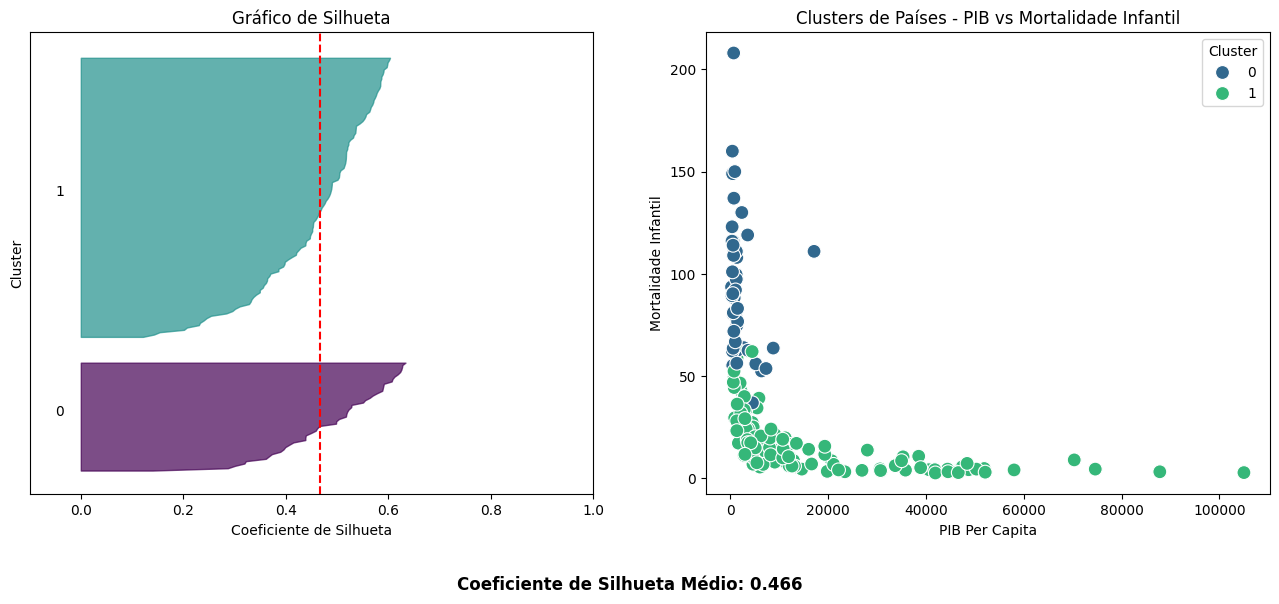

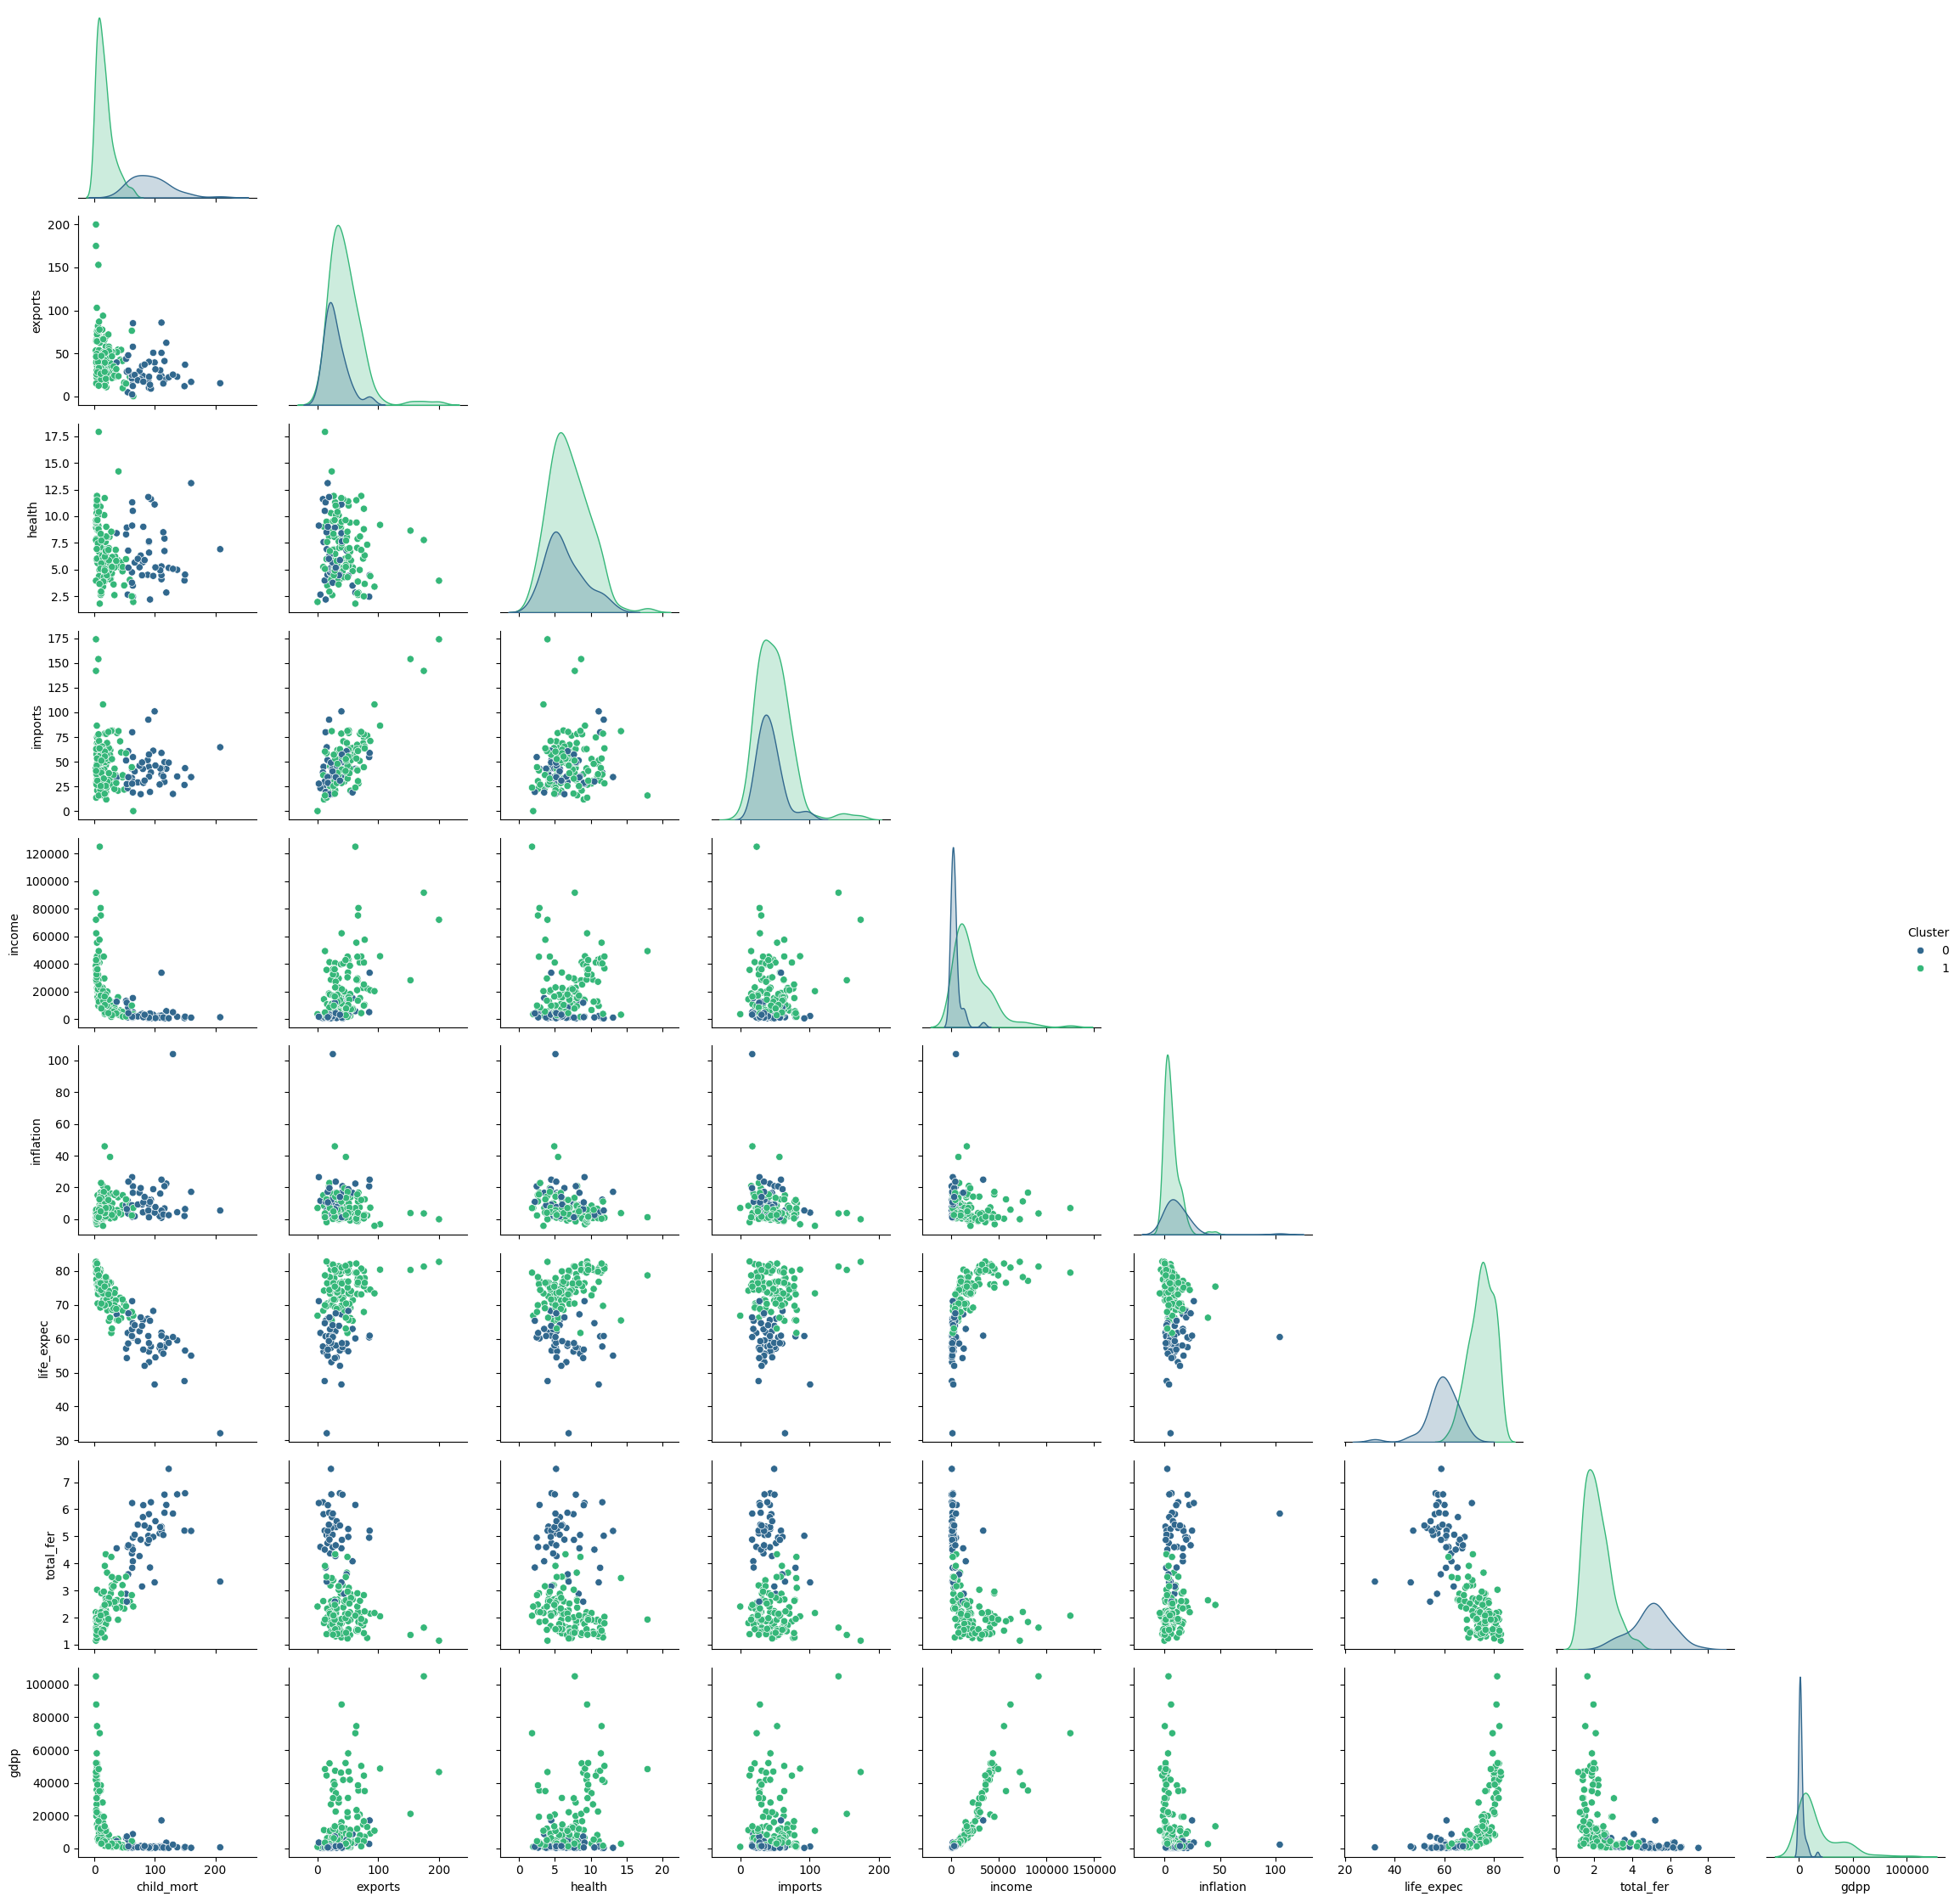

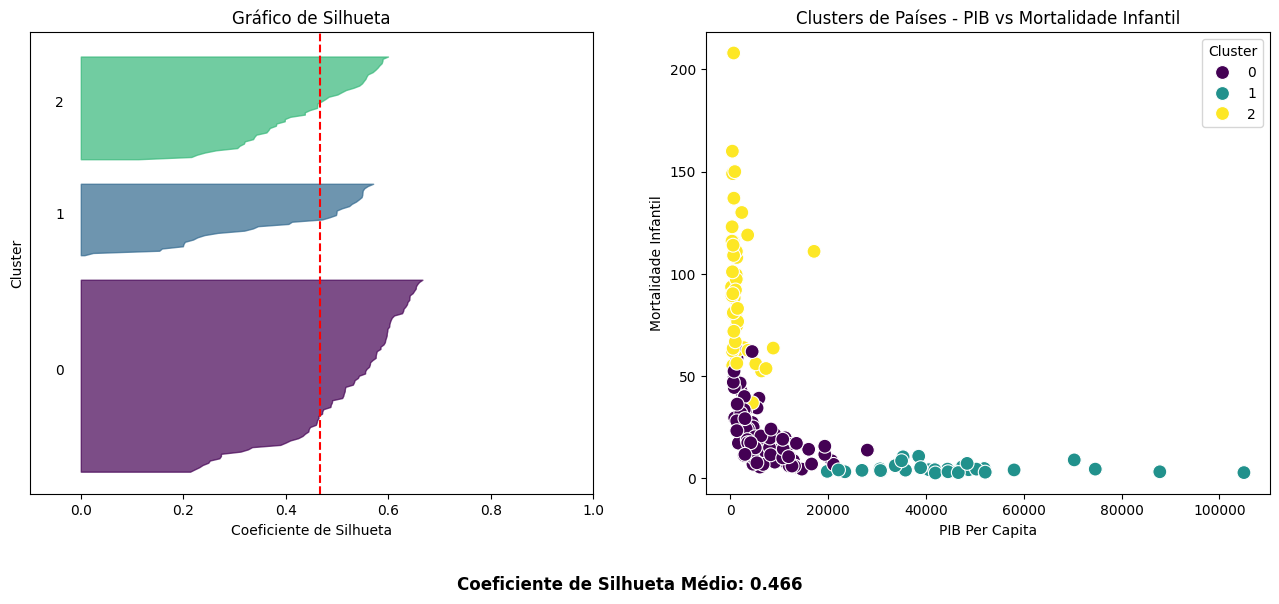

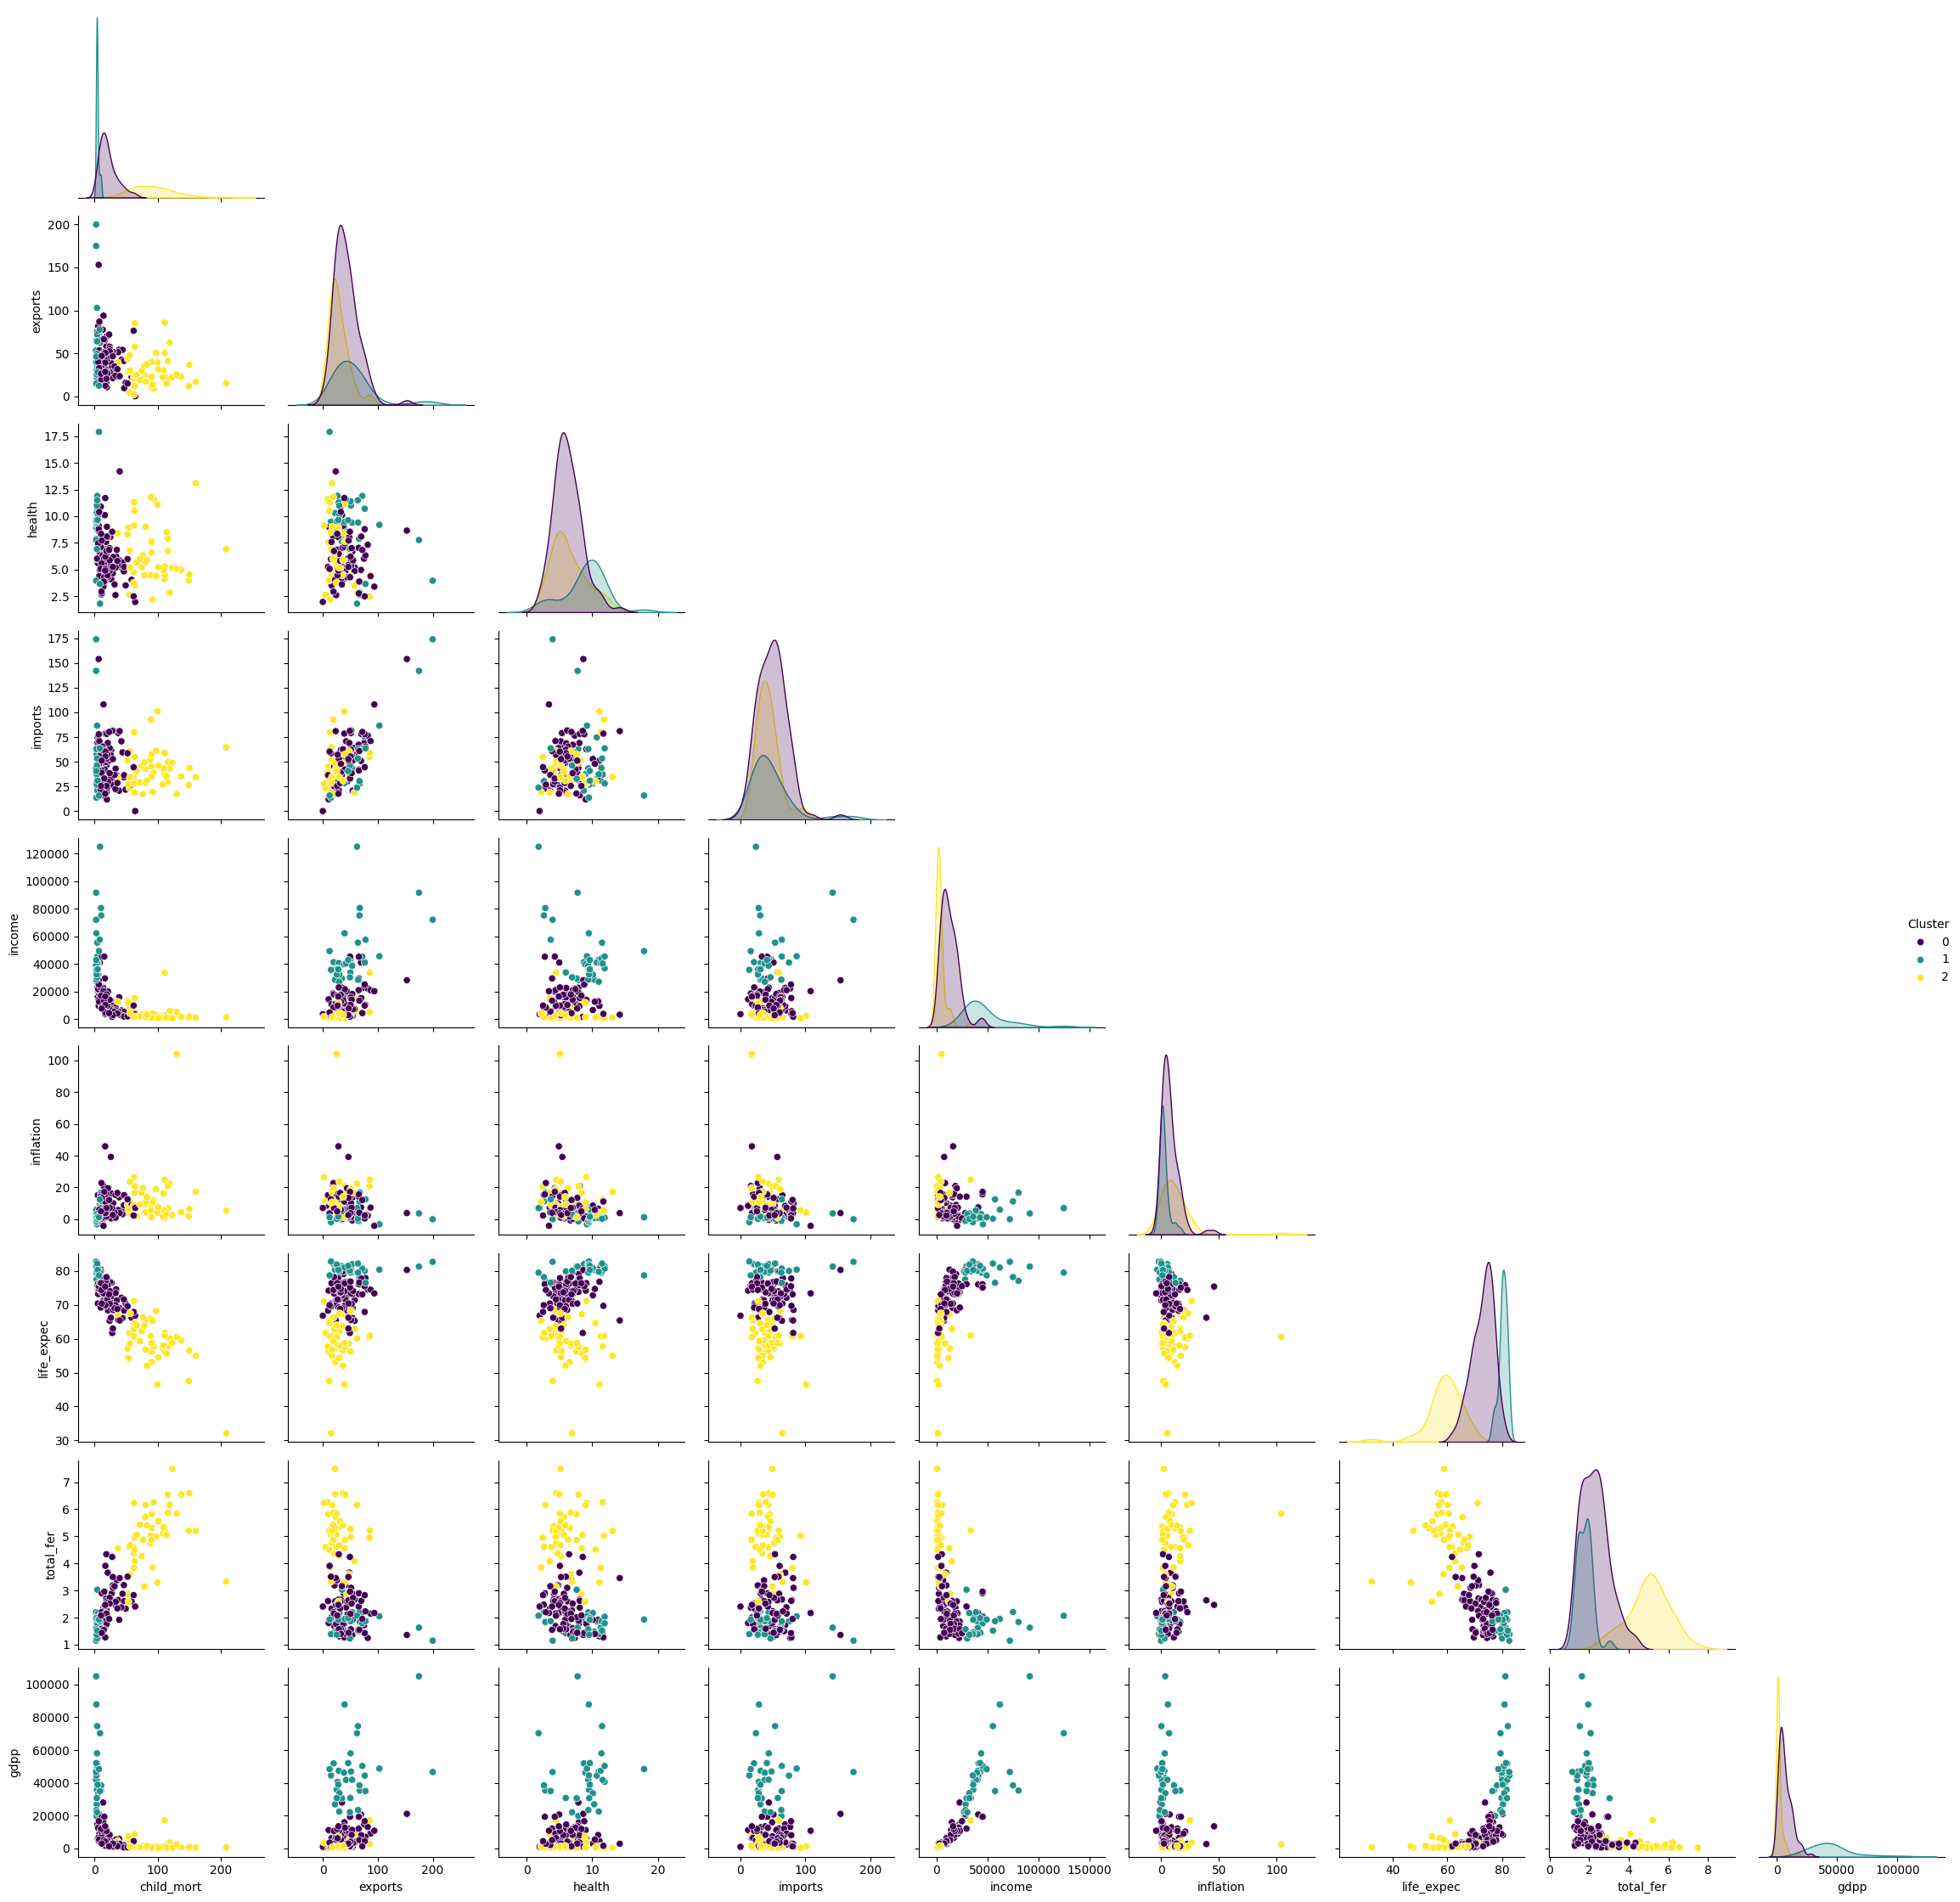

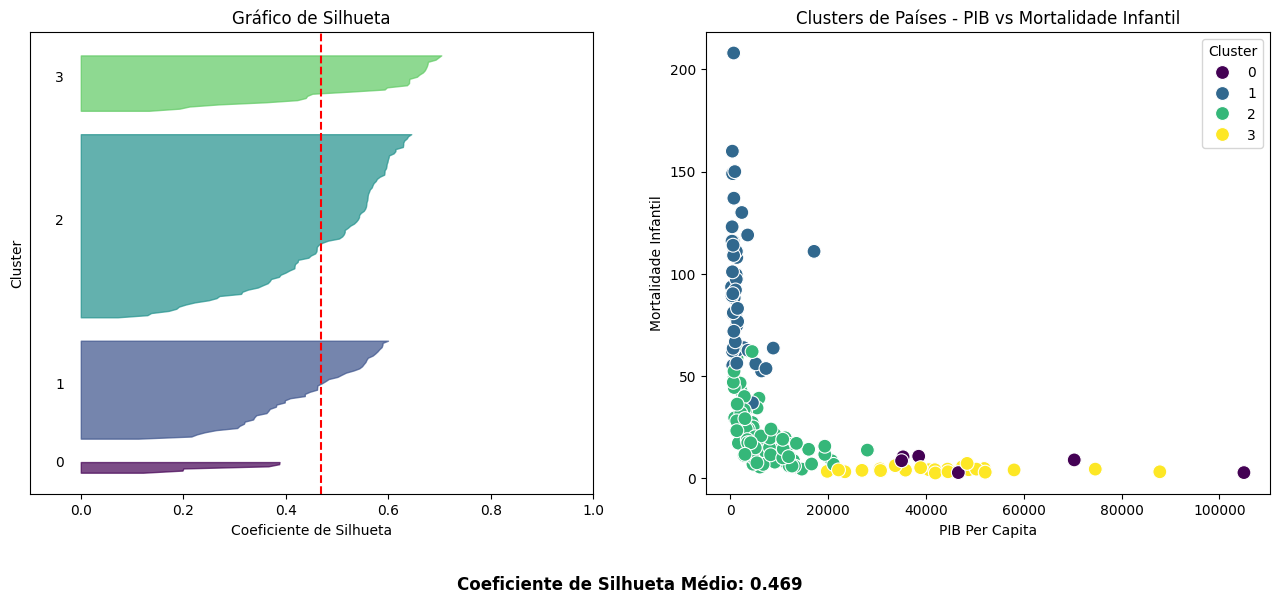

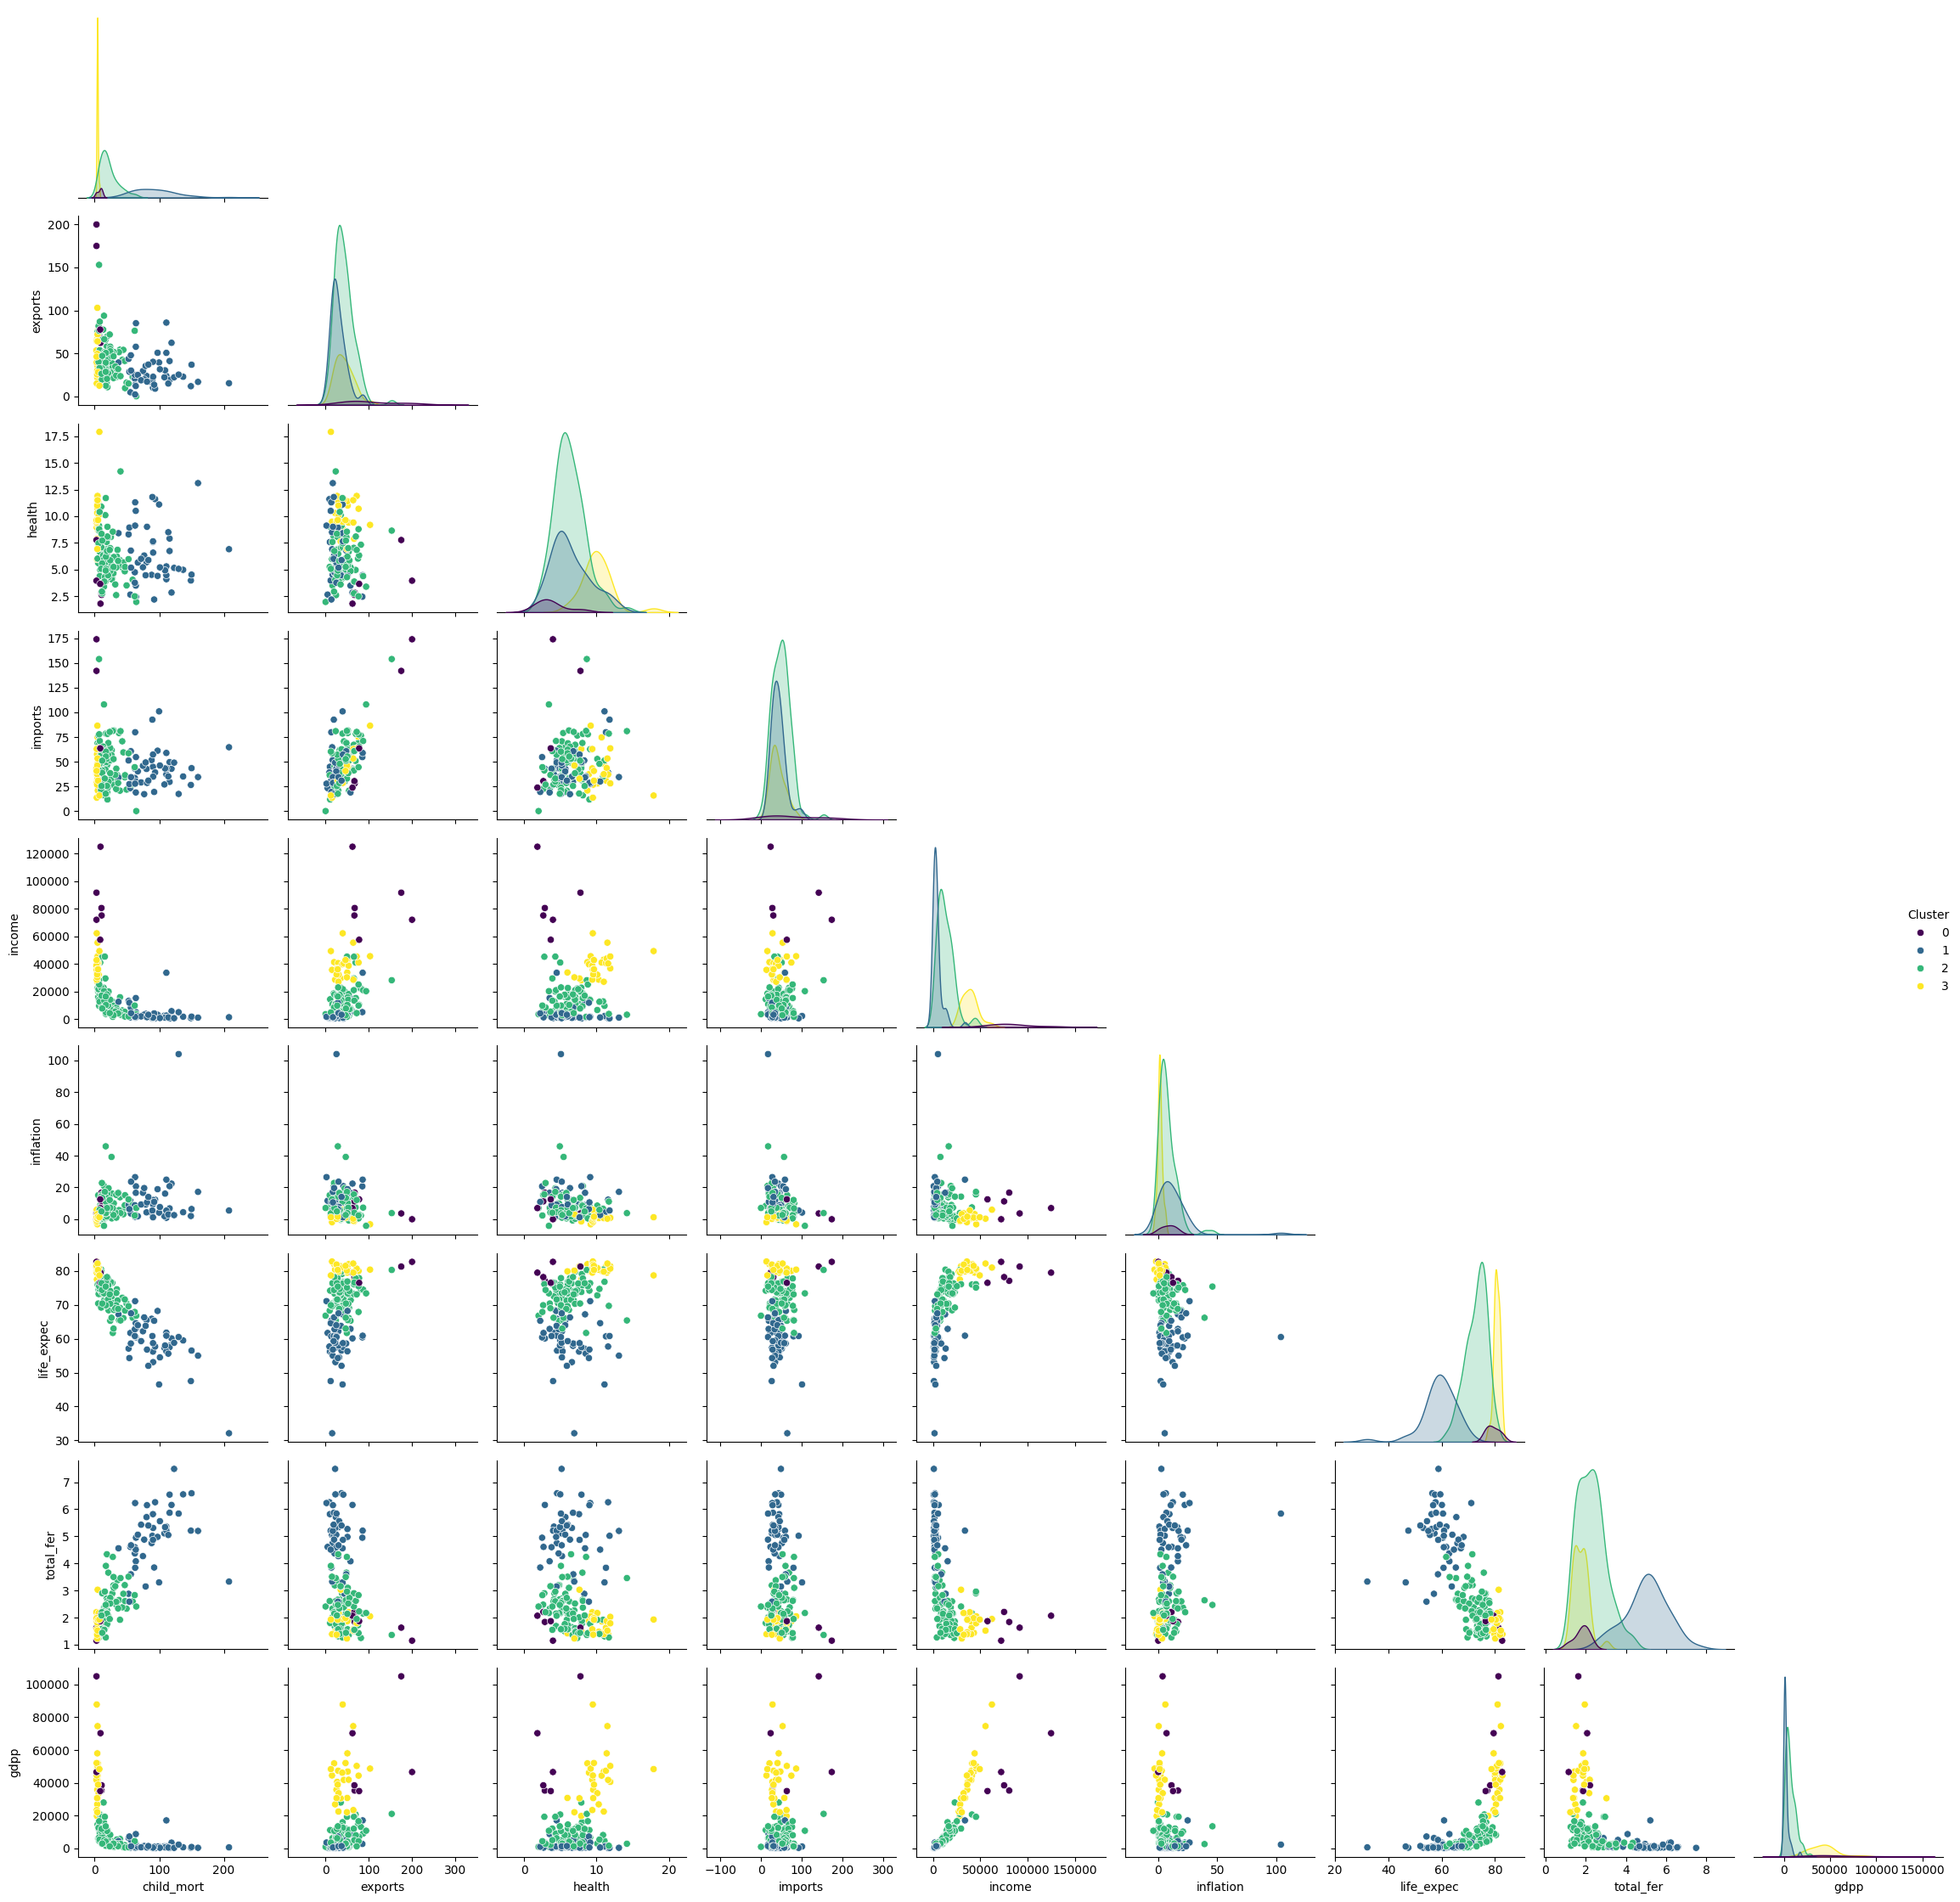

In [ ]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

# Definir o número de clusters
cluster_range = range(2, 5)

for k in cluster_range:
  # Aplicar K-Means
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  df['Cluster'] = kmeans.fit_predict(principalDf)

  # Calcular métricas de silhueta
  silhouette_avg = silhouette_score(principalDf, df['Cluster'])
  sample_silhouette_values = silhouette_samples(principalDf, df['Cluster'])

  # Criar figura com 2 gráficos lado a lado
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

  ### 1. Gráfico de Silhueta ###
  ax1.set_xlim([-0.1, 1])
  ax1.set_ylim([0, len(principalDf) + (k + 1) * 10])

  y_lower = 10
  for i in range(k):
      ith_cluster_silhouette_values = sample_silhouette_values[df['Cluster'] == i]
      ith_cluster_silhouette_values.sort()

      size_cluster_i = ith_cluster_silhouette_values.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cm.viridis(float(i) / k)
      ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

      ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
      y_lower = y_upper + 10  # Adiciona espaço entre os clusters

  ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
  ax1.set_title("Gráfico de Silhueta")
  ax1.set_xlabel("Coeficiente de Silhueta")
  ax1.set_ylabel("Cluster")
  ax1.set_yticks([])

  ### 2. Scatterplot dos Clusters ###
  sns.scatterplot(data=df, x='gdpp', y='child_mort', hue='Cluster', palette="viridis", s=100, ax=ax2)
  ax2.set_title('Clusters de Países - PIB vs Mortalidade Infantil')
  ax2.set_xlabel('PIB Per Capita')
  ax2.set_ylabel('Mortalidade Infantil')
  ax2.legend(title="Cluster")

  fig.text(0.5, -0.05, f"Coeficiente de Silhueta Médio: {silhouette_avg:.3f}", ha="center", fontsize=12, fontweight="bold")
  sns.pairplot(df,corner=True, hue="Cluster", palette="viridis", diag_kind="kde")
  plt.tight_layout()
  plt.show()

In [ ]:
# Selecionando k = 3:
kmeans = KMeans(3, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(principalDf)
# Estatísticas descritivas por cluster
numeric_columns = df.select_dtypes(include='number')
numeric_columns.groupby('Cluster').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,21.428736,42.290678,6.244713,49.085815,12968.620690,7.473920,72.967816,2.284828,6934.045977
1,4.775758,55.024242,8.929394,47.606061,46957.575758,2.557879,80.387879,1.762121,44587.878788
2,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979


# Ao realizar o algoritmo de K-Means com os mesmos parâmetros do Hand on 4, mas agora utilizando a PCA, houve uma melhoria significativa do coeficiente de silhueta. Isso indica que a PCA ajudou a reduzir o ruído e destacar os padrões nos dados, resultando em uma melhor separação entre os clusters. Dessa forma, a aplicação da PCA antes do K-Means demonstrou ser uma estratégia eficaz para otimizar a segmentação dos dados.

## TSNE

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=5, method='exact')

# Ajusta o modelo t-SNE aos seus dados
tsne_components = tsne.fit_transform(X_scaled)

# Cria um DataFrame com os componentes t-SNE
tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE component 1', 't-SNE component 2', 't-SNE component 3', 't-SNE component 4', 't-SNE component 5'])

tsne_df

,t-SNE component 1,t-SNE component 2,t-SNE component 3,t-SNE component 4,t-SNE component 5
0,-10.492121,-11.247973,4.440156,-6.182821,2.826779
1,0.026736,-6.957757,-8.849263,-9.536254,-5.582652
2,-9.576446,0.788301,14.475681,3.947635,-8.353124
3,-5.297225,-14.980221,10.243848,-4.486751,-14.999704
4,7.627225,2.596394,-14.400914,2.185225,-7.828335
...,...,...,...,...,...
162,-7.550794,-6.740585,-5.050180,16.003847,16.534138
163,6.033957,-2.196423,20.739967,-7.366475,-9.870095
164,0.578759,-0.950388,6.759248,-7.570805,2.009697
165,-15.370562,-0.644169,3.624467,-13.454714,-13.980669


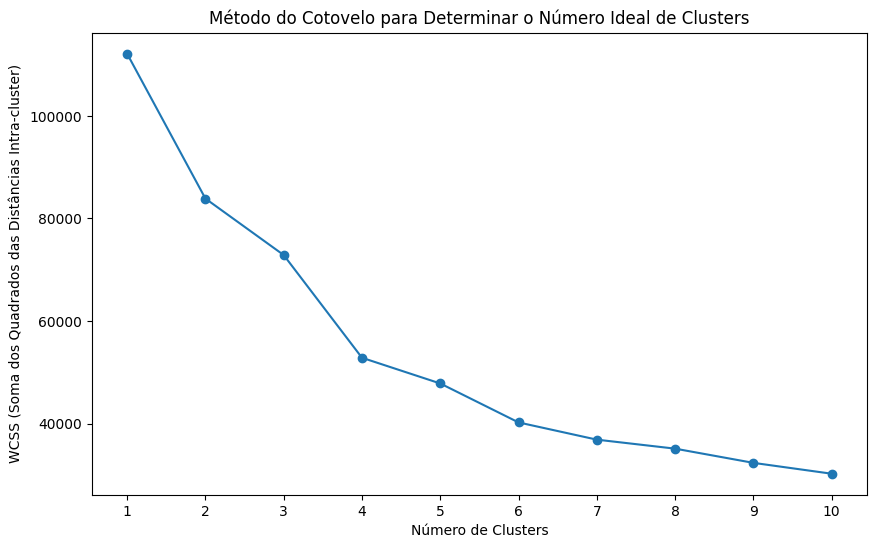

In [ ]:
# Determinar o número ideal de clusters usando o método do cotovelo
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(tsne_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Método do Cotovelo para Determinar o Número Ideal de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Soma dos Quadrados das Distâncias Intra-cluster)')
plt.xticks(range(1, 11))
plt.show()

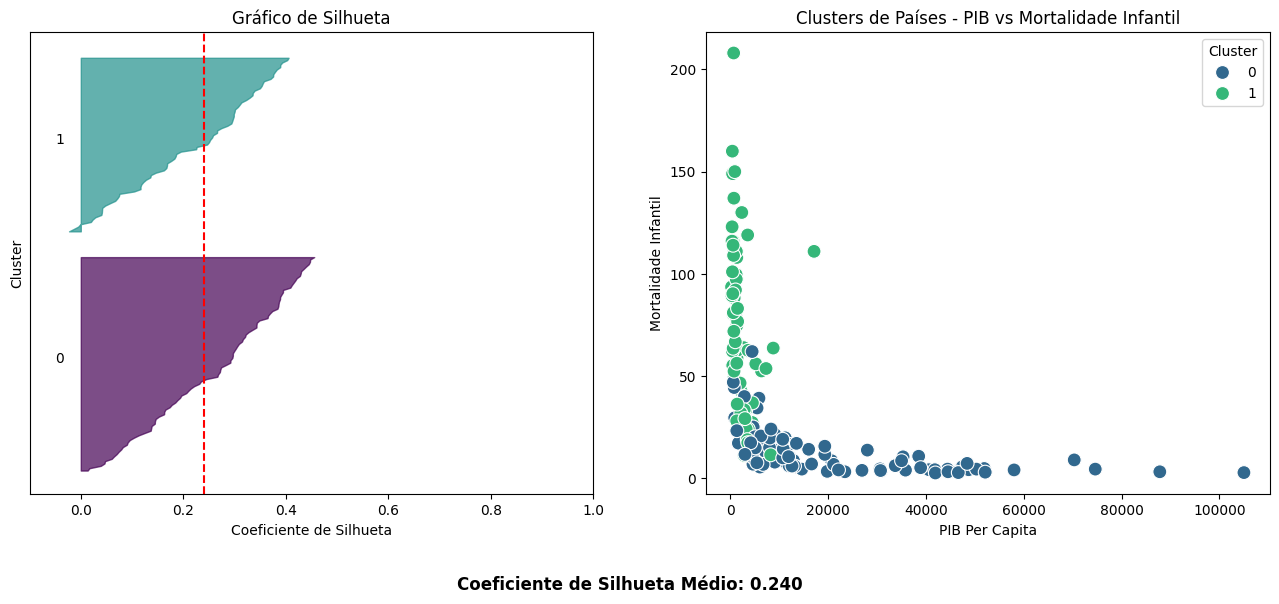

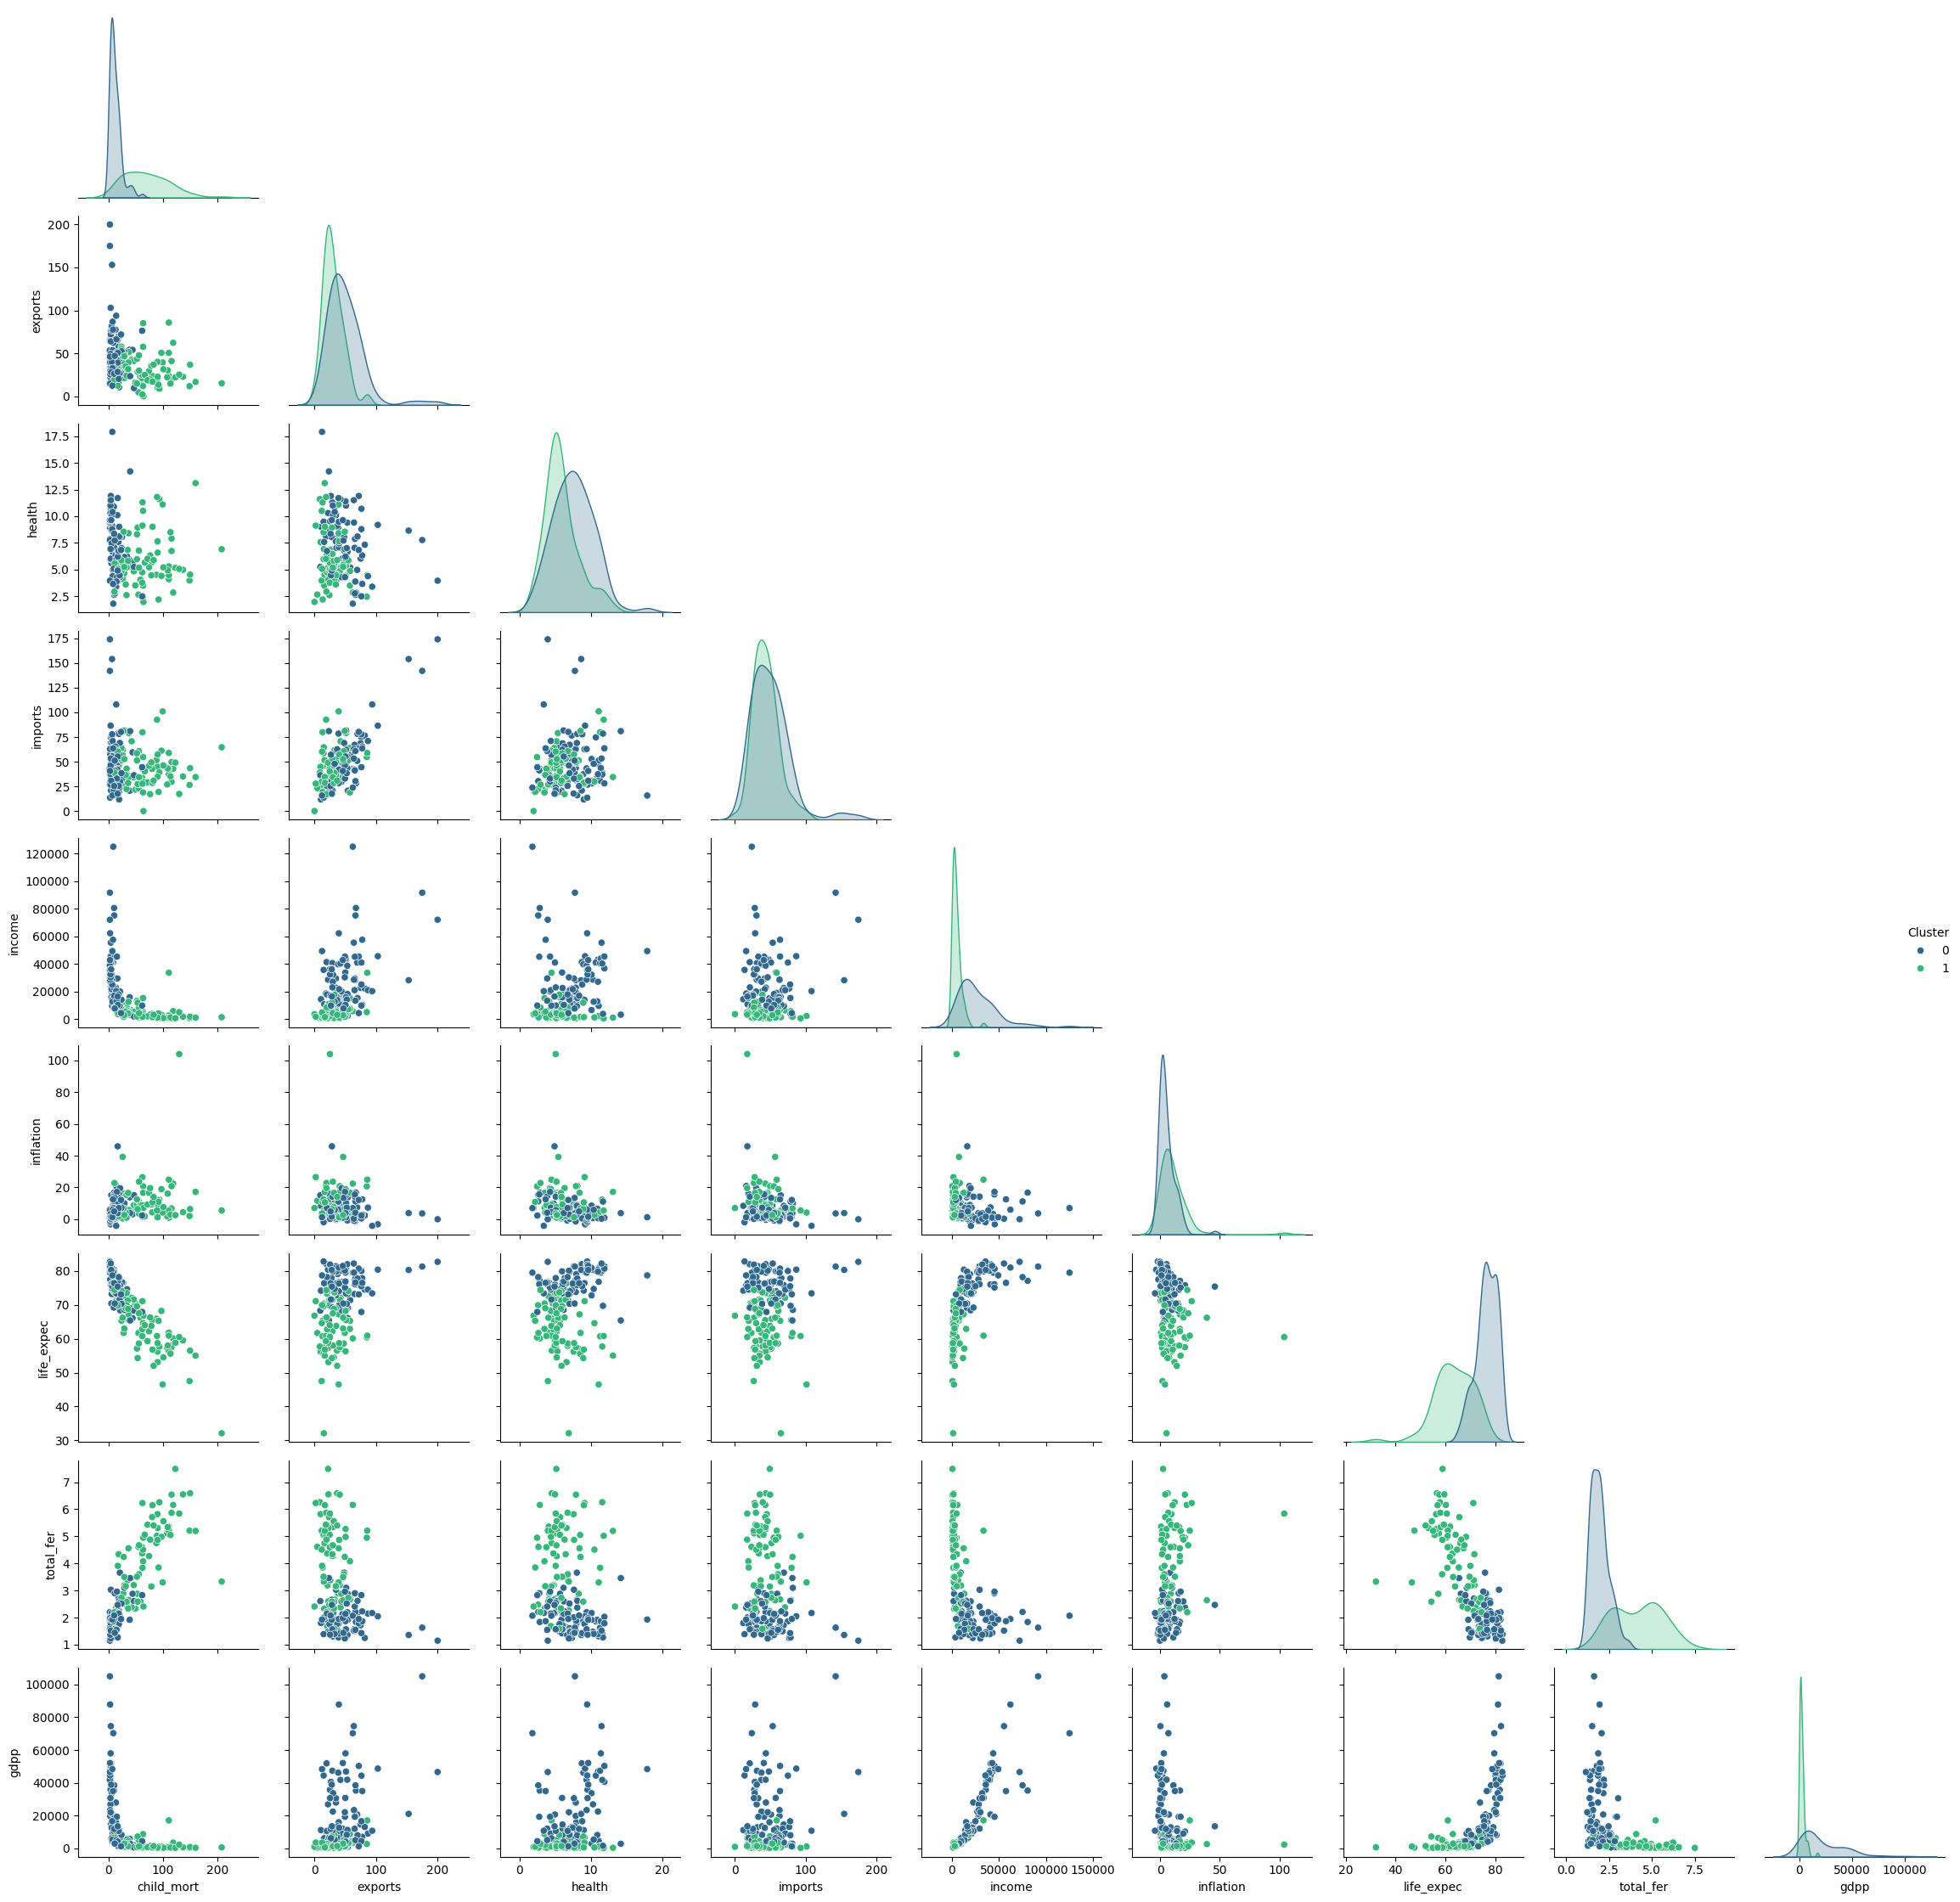

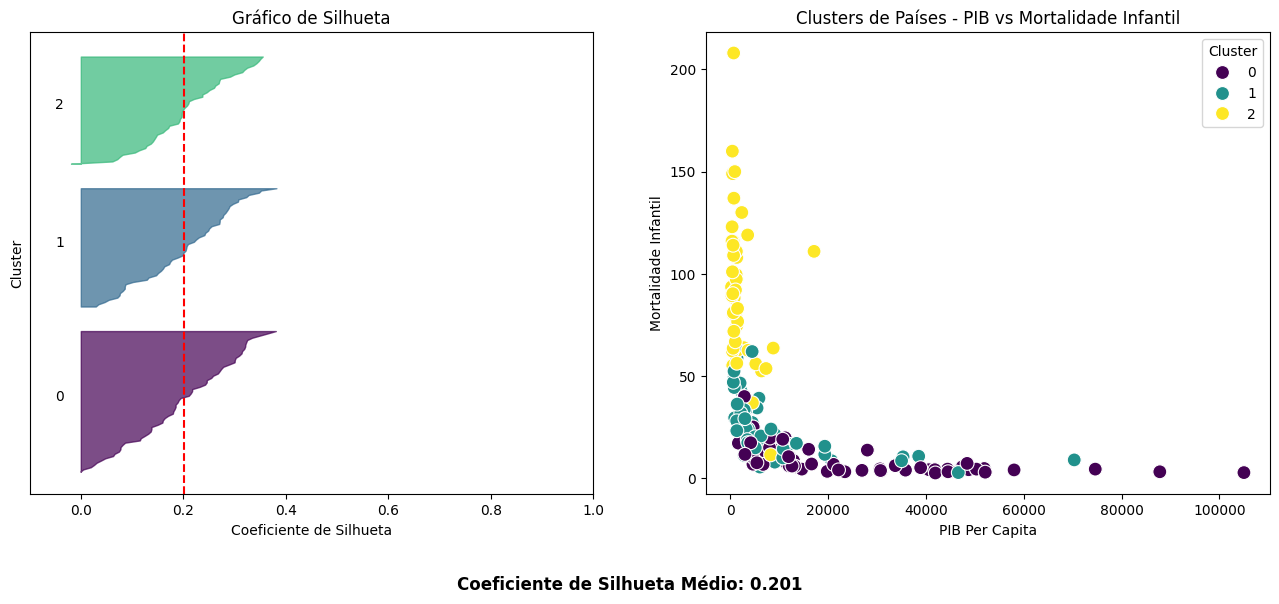

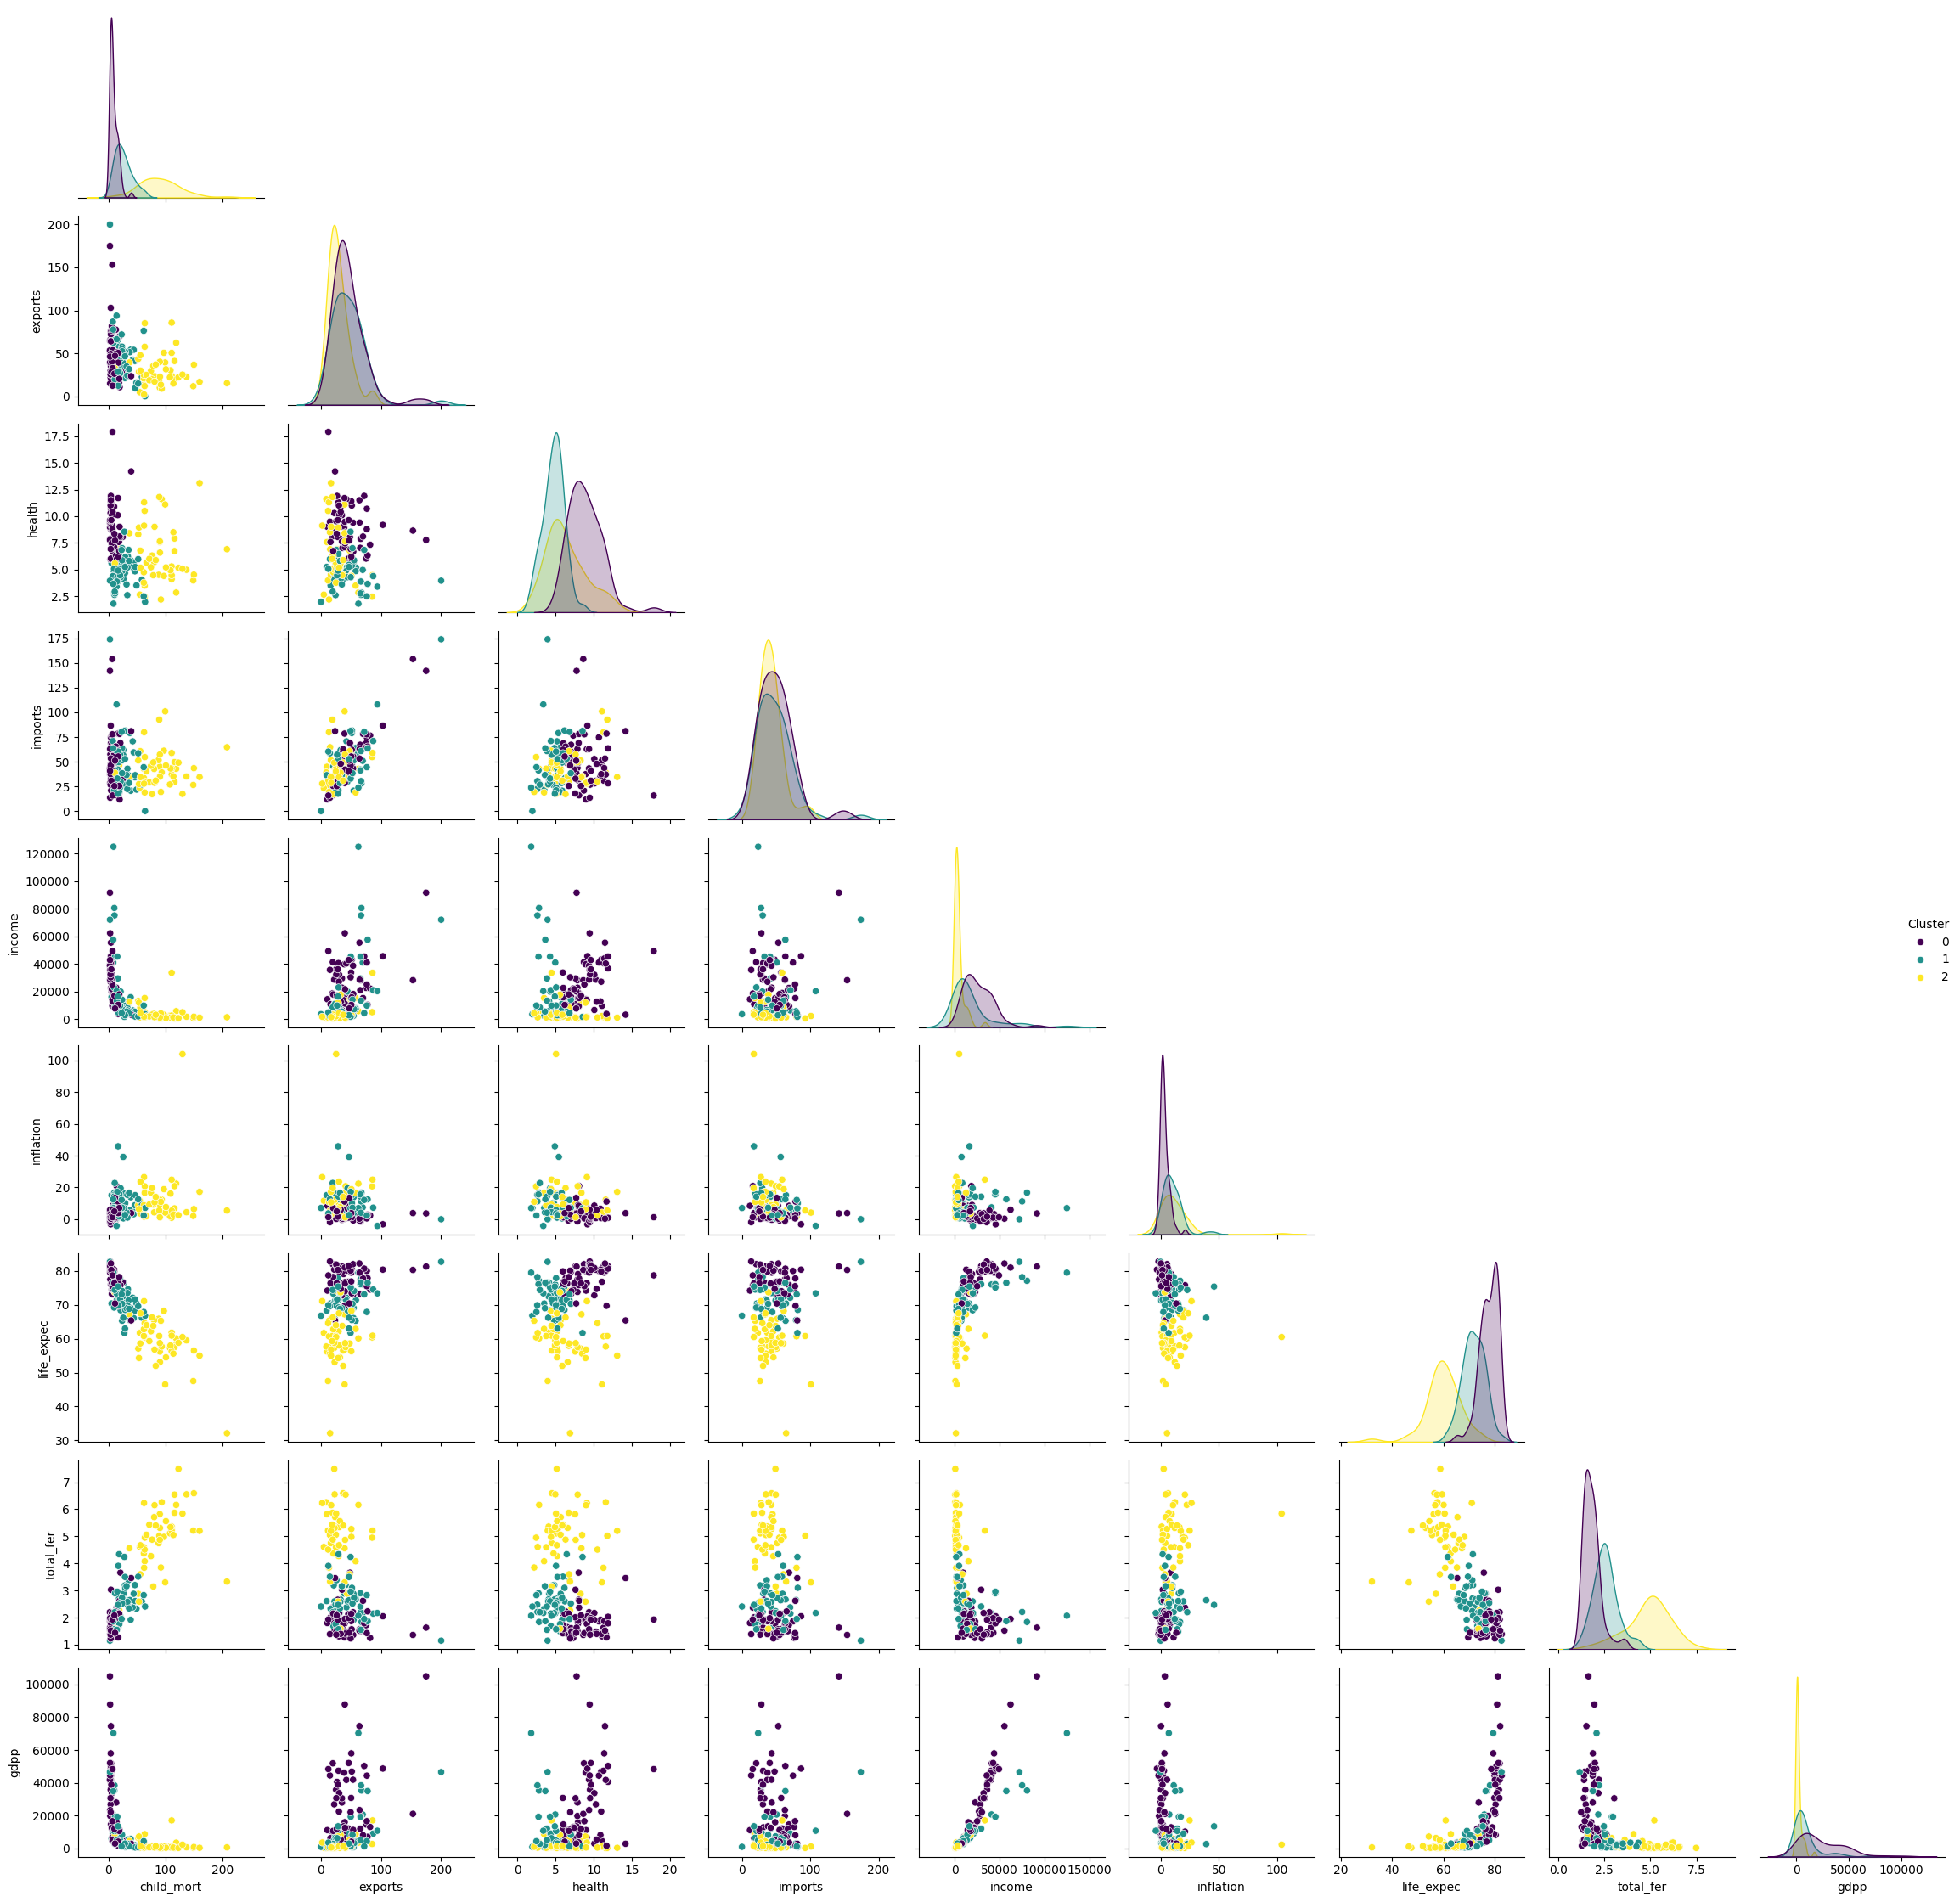

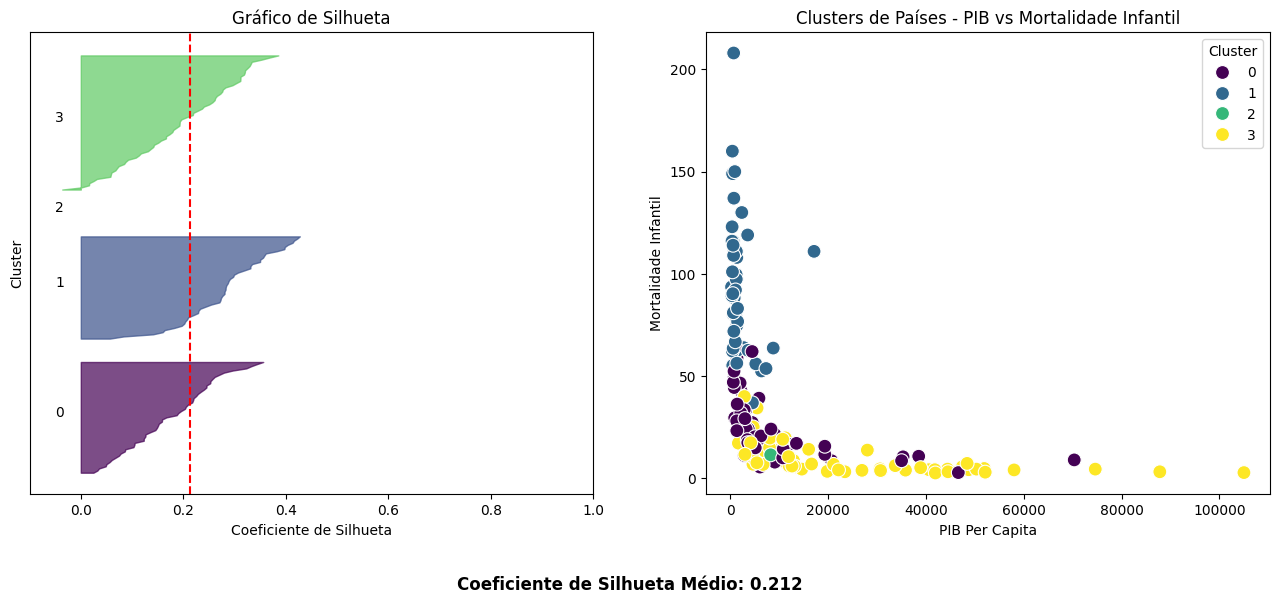

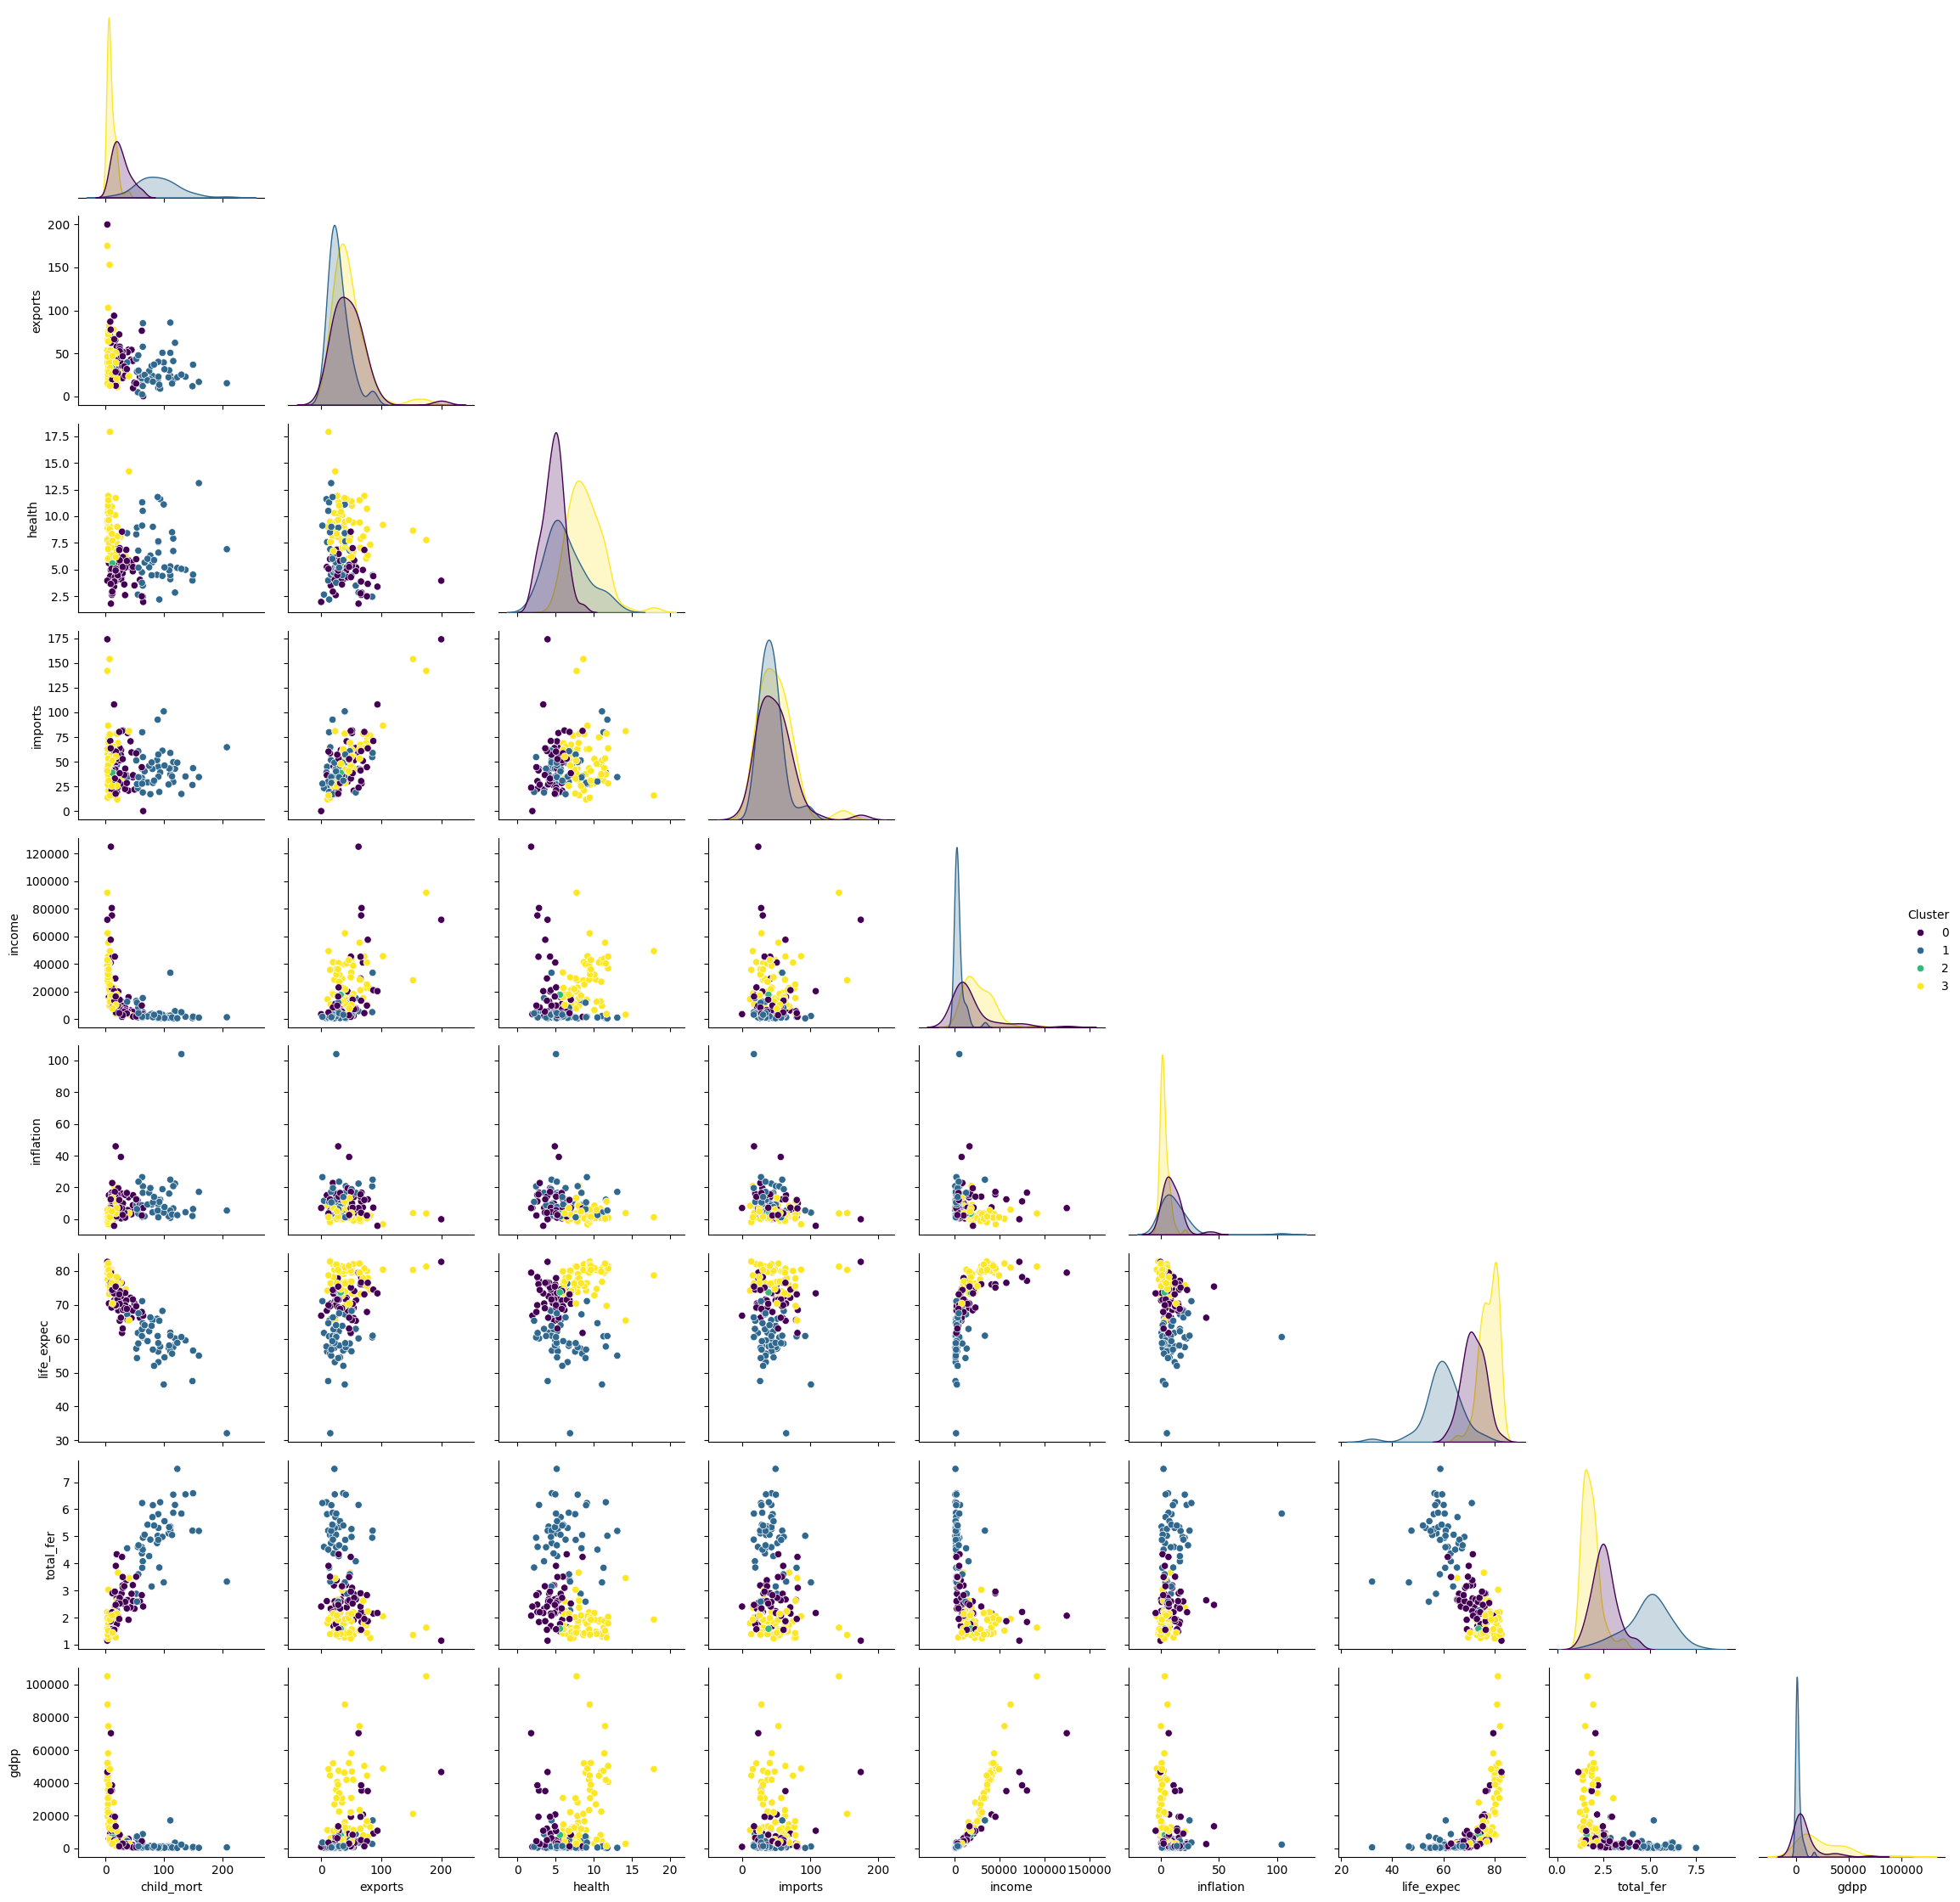

In [ ]:
# Definir o número de clusters
cluster_range = range(2, 5)

for k in cluster_range:
  # Aplicar K-Means
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  df['Cluster'] = kmeans.fit_predict(tsne_df)

  # Calcular métricas de silhueta
  silhouette_avg = silhouette_score(tsne_df, df['Cluster'])
  sample_silhouette_values = silhouette_samples(tsne_df, df['Cluster'])

  # Criar figura com 2 gráficos lado a lado
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

  ### 1. Gráfico de Silhueta ###
  ax1.set_xlim([-0.1, 1])
  ax1.set_ylim([0, len(tsne_df) + (k + 1) * 10])

  y_lower = 10
  for i in range(k):
      ith_cluster_silhouette_values = sample_silhouette_values[df['Cluster'] == i]
      ith_cluster_silhouette_values.sort()

      size_cluster_i = ith_cluster_silhouette_values.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cm.viridis(float(i) / k)
      ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

      ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
      y_lower = y_upper + 10  # Adiciona espaço entre os clusters

  ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
  ax1.set_title("Gráfico de Silhueta")
  ax1.set_xlabel("Coeficiente de Silhueta")
  ax1.set_ylabel("Cluster")
  ax1.set_yticks([])

  ### 2. Scatterplot dos Clusters ###
  sns.scatterplot(data=df, x='gdpp', y='child_mort', hue='Cluster', palette="viridis", s=100, ax=ax2)
  ax2.set_title('Clusters de Países - PIB vs Mortalidade Infantil')
  ax2.set_xlabel('PIB Per Capita')
  ax2.set_ylabel('Mortalidade Infantil')
  ax2.legend(title="Cluster")

  fig.text(0.5, -0.05, f"Coeficiente de Silhueta Médio: {silhouette_avg:.3f}", ha="center", fontsize=12, fontweight="bold")
  sns.pairplot(df,corner=True, hue="Cluster", palette="viridis", diag_kind="kde")
  plt.tight_layout()
  plt.show()

Ao realizar o algoritmo de K-Means com os mesmos parâmetros, mas agora utilizando o t-SNE em vez da PCA, observou-se uma piora no coeficiente de silhueta. Isso indica que os clusters ficaram menos bem definidos e com maior sobreposição.

Essa piora pode ter ocorrido por alguns motivos:

t-SNE não preserva a estrutura global dos dados, focando mais na relação local entre os pontos, o que pode atrapalhar a separação dos clusters para algoritmos como o K-Means.
Sensibilidade aos hiperparâmetros: Parâmetros como perplexity e learning_rate podem influenciar drasticamente a distribuição dos pontos, gerando agrupamentos menos estáveis.
Redução de dimensionalidade diferente: Enquanto a PCA mantém as direções de maior variância, o t-SNE reconfigura os dados de maneira não linear, podendo distorcer a relação entre os clusters quando aplicada antes do K-Means.
Dessa forma, para esse conjunto de dados, a PCA se mostrou mais eficiente para destacar padrões úteis para o K-Means, enquanto o t-SNE pode ser mais adequado para visualização do que para clustering.